# Mid-term project: Rental Price prediction
## Author: Yuxiang MA
## Date: 2025-10-23
## Version: 1.0

### 包的调用和数据录入

In [636]:
# 基础包
import pandas as pd, numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error

In [637]:
# 读入
train = pd.read_csv('ruc_Class25Q2_train_rent.csv')

# 去除列名中的所有空格
train.columns = [col.replace(" ", "") for col in train.columns]

### 查看数据情况（空缺值、总数）

In [638]:
# 查看样本数据量
train.info() # 98898 个样本

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98899 entries, 0 to 98898
Data columns (total 46 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   城市       98899 non-null  int64  
 1   户型       98898 non-null  object 
 2   装修       25410 non-null  object 
 3   Price    98899 non-null  float64
 4   楼层       98894 non-null  object 
 5   面积       98899 non-null  object 
 6   朝向       98894 non-null  object 
 7   交易时间     98899 non-null  object 
 8   付款方式     80476 non-null  object 
 9   租赁方式     98899 non-null  object 
 10  电梯       98895 non-null  object 
 11  车位       24764 non-null  object 
 12  用水       81159 non-null  object 
 13  用电       81575 non-null  object 
 14  燃气       94317 non-null  object 
 15  采暖       34412 non-null  object 
 16  租期       51966 non-null  object 
 17  配套设施     68448 non-null  object 
 18  lon      98899 non-null  float64
 19  lat      98899 non-null  float64
 20  年份       98899 non-null  float64
 21  区县       942

In [639]:
# 查看空缺
train.isnull().sum().sort_values()

城市             0
Price          0
交易时间           0
面积             0
租赁方式           0
年份             0
lon            0
lat            0
客户反馈           0
户型             1
电梯             4
朝向             5
楼层             5
燃气          4582
楼栋总数        4631
房屋总数        4631
coord_x     4631
coord_y     4631
区县          4677
板块          5144
用电         17324
用水         17740
付款方式       18423
物业类别       20124
产权描述       20124
建筑结构       20741
供水         21194
供电         21200
物业费        22159
容积率        24080
绿化率        24402
燃气费        25057
停车位        25479
停车费用       26003
建筑年代       26149
开发商        26984
物业公司       28753
配套设施       30451
租期         46933
物业办公电话     60692
供暖         61204
采暖         64487
环线位置       69663
供热费        70064
装修         73489
车位         74135
dtype: int64

In [640]:
# 随机查看10个
train.sample(n=10)

,城市,户型,装修,Price,楼层,面积,朝向,交易时间,付款方式,租赁方式,...,供水,供暖,供电,燃气费,供热费,停车位,停车费用,coord_x,coord_y,客户反馈
80185,8,3室2厅,NaN,2.622427e+05,高楼层/29层,90.00㎡,西南,2024-08-05,NaN,整租,...,商水/民水,自采暖,商电/民电,2.95元/m³,3元/㎡,1647.0,300,103.739908,25.973646,说句实话，电梯停用频繁，说白了，社区活动多
70304,7,3居室,NaN,3.621773e+05,5/15层,12.19㎡,北,2024-06-08,季付价,合租,...,民水,NaN,民电,3.5元/m³,NaN,551.0,250,114.951949,23.544168,门锁完好，当然了，房屋采光佳，潮臭
43131,3,3室2厅,NaN,5.743254e+05,高楼层/6层,200.00㎡,南 北,2024-09-25,季付价,整租,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.679569,32.372397,洗衣阳台实用，光线均匀，感受上，厕所漏水
87745,10,2室1厅,NaN,8.495926e+05,中楼层/43层,76.97㎡,北,2024-05-21,月付价,整租,...,商水/民水,NaN,商电/民电,3.45元/m³,NaN,497.0,800-1000,114.370651,24.133055,其实，墙皮剥落，在现实中，绿植多，噪音扰民
60771,4,2室1厅0卫,精装修,1.459878e+06,3/34层,105.97㎡,南,2024-12-10,季付价,整租,...,商水/民水,自采暖,商电/民电,3元/m³,NaN,5109.0,地下车位租赁每月1000元左右。地上车位租赁150/月,122.487870,32.268633,可以看到，装修好，标准水平，采暖良好
41991,3,1室1厅,NaN,6.144594e+05,低楼层/15层,70.00㎡,东,2024-08-24,季付价,整租,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.766772,32.304424,安全感强，大体情况如此，噪声源近
65496,5,2室2厅1卫,精装修,2.209615e+05,低楼层/11层,81.54㎡,南,2025-01-24,NaN,整租,...,民水,NaN,民电,3.45元/m³,NaN,1194.0,200,114.331603,23.174370,老话说得好，漏电隐患，通风一般
73887,7,2室2厅1卫,精装修,4.810299e+05,低楼层/29层,79.00㎡,东南,2024-10-11,月付价,整租,...,民水,NaN,民电,3.5元/m³,1元/㎡,740.0,200,115.183560,23.682740,换个角度看，装修高档，整体观感还行，空气清爽，在某种程度上，隔音好
29154,2,2室1厅,NaN,3.322656e+05,中楼层/32层,85.00㎡,东南,2024-08-26,季付价,整租,...,商水/民水,NaN,商电/民电,1.96-1.98元/m³,NaN,2000.0,450,107.559132,30.672012,总体看，陷阱条款，其实，门窗松动，采暖良好
7202,0,1室1厅,NaN,1.689399e+05,中楼层/5层,36.00㎡,南,2024-08-12,NaN,整租,...,民水,集中供暖,民电,2.61元/m³,30元/㎡,58.0,暂无,117.026793,40.711022,看起来，电器齐全，有种感觉，动静分离


### 数据清洗中

In [641]:
# 去除单位，并且将非区间数据的转化为数字

# 需要清洗的列 "面积", "套内面积", "房屋总数", "楼栋总数", "绿化率", "物业费", "燃气费", "供热费"
train['面积'] = train['面积'].str.replace('㎡', '', regex=False)
train['面积'] = train['面积'].astype(float)

train['房屋总数'] = train['房屋总数'].str.replace('户', '', regex=False)
train['房屋总数'] = train['房屋总数'].astype(float)

train['楼栋总数'] = train['楼栋总数'].str.replace('栋', '', regex=False)
train['楼栋总数'] = train['楼栋总数'].astype(float)

train['绿化率'] = train['绿化率'].str.replace('%', '', regex=False)
train['绿化率'] = train['绿化率'].astype(float)

# 存在-的区间
train['物业费'] = train['物业费'].str.replace('元/月/㎡', '', regex=False)
train['燃气费'] = train['燃气费'].str.replace('元/m³', '', regex=False)
train['供热费'] = train['供热费'].str.replace('元/㎡', '', regex=False)

train.sample(10)

,城市,户型,装修,Price,楼层,面积,朝向,交易时间,付款方式,租赁方式,...,供水,供暖,供电,燃气费,供热费,停车位,停车费用,coord_x,coord_y,客户反馈
74510,7,1室1厅1卫,精装修,9.635104e+05,高楼层/30层,41.0,东北,2024-10-24,月付价,整租,...,商水/民水,无供暖,商电/民电,3.5,NaN,2072.0,250,115.066963,23.540953,卫生死角多，整体还可以，采光拥挤，采暖不足
71544,7,4室2厅,NaN,1.847465e+06,中楼层/30层,143.0,南,2024-08-31,月付价,整租,...,民水,NaN,民电,3.5,NaN,1145.0,251,115.178279,23.582748,好像，交通流量适中，总归还是，设备故障频繁，地段条件普通
25711,2,3室2厅,NaN,2.690715e+05,高楼层/11层,97.0,西南,2024-05-22,季付价,整租,...,民水,NaN,民电,2,1,330.0,2,107.520446,30.550126,垃圾处理正常，从我看，配套贴心，管道异响
40917,3,3居室,NaN,2.725473e+05,6/30层,25.0,南,2024-08-12,季付价,合租,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.793915,32.348335,话又说回来，靠近公交站，某种意义上，周边生活设施齐全，严格来说，区域发展中等
48721,3,2室2厅1卫,精装修,7.210301e+05,中楼层/27层,80.0,南,2025-02-02,季付价,整租,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.768767,32.270354,与其说，隔音出色，总体印象中，儿童设施完善，总体还不错，储物空间多
67845,7,1室1厅,NaN,7.110265e+05,低楼层/32层,47.0,北,2024-07-22,月付价,整租,...,民水,无供暖,民电,3.1,NaN,105.0,250,115.108643,23.536857,听说，窗外风景佳，通风差
45070,3,3室2厅1卫,精装修,6.272975e+05,高楼层/18层,136.0,南 北,2024-10-18,季付价,整租,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122.023995,32.424945,客厅宽度标准，商业配套稳定
36234,3,2室1厅,NaN,3.272264e+05,中楼层/26层,109.0,南,2024-05-31,季付价,整租,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.819509,32.652612,空间利用率中等，另一方面，采光差，视觉上感觉，门窗进风
45105,3,3室2厅1卫,精装修,3.546106e+05,高楼层/28层,91.0,南 北,2024-10-19,季付价,整租,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.881351,32.293471,感觉上，储物少，还算，隔音一般，个人觉得，房东好沟通
23990,2,3室1厅,NaN,3.299956e+05,中楼层/33层,115.0,南,2024-05-23,季付价,整租,...,民水,NaN,民电,2,1,505.0,350,107.547300,30.555197,管线老化，细看下来，楼体新


In [642]:
# 计算每列缺失值数量
missing_counts = train.isna().sum()

# 找出缺失数量相同的列
duplicates = missing_counts[missing_counts.duplicated(keep=False)]

# 按缺失数量分组显示
result = duplicates.groupby(duplicates).apply(lambda x: list(x.index))

print(result)

0        [城市, Price, 面积, 交易时间, 租赁方式, lon, lat, 年份, 客户反馈]
5                                               [楼层, 朝向]
4631                      [房屋总数, 楼栋总数, coord_x, coord_y]
20124                                       [物业类别, 产权描述]
dtype: object


### 将一些数值数据进行拆分，转化为数字

In [643]:
# (1)户型
# 定义一个函数解析户型
print(train['户型'].value_counts()) # 208类，室厅，室厅卫，居室（全部换成室），房间（换成室），未知（换成0），.（换成NULL），车库

户型
2室1厅      14437
3室2厅      13514
1室1厅      10580
2室1厅1卫     7744
2室2厅       7103
          ...  
6室1厅3卫        1
5室3厅6卫        1
9室2厅          1
9室2厅5卫        1
1室1厅3卫        1
Name: count, Length: 208, dtype: int64


In [644]:
train['户型'] = train['户型'].replace({
    '居室': '室', 
    '房间': '室', 
    '未知': '0', 
    '.': '0室0厅0卫'
})


In [645]:
import pandas as pd
import re

# Function to extract the number of rooms, living rooms, and bathrooms
def extract_features(huxing):
    # Ensure the input is a string and handle NaN or non-string values
    huxing = str(huxing) if pd.notna(huxing) else ""
    
    # Use regex to find all the numbers for '室', '厅', and '卫'
    rooms = re.findall(r'(\d+)室', huxing)
    halls = re.findall(r'(\d+)厅', huxing)
    baths = re.findall(r'(\d+)卫', huxing)
    
    # Assign default values if not found
    rooms = int(rooms[0]) if rooms else 0
    halls = int(halls[0]) if halls else 0
    baths = int(baths[0]) if baths else 0
    
    return rooms, halls, baths

# Apply the function to create new columns
train[['户型_室', '户型_厅', '户型_卫']] = train['户型'].apply(lambda x: pd.Series(extract_features(x)))


In [646]:

# Display the transformed DataFrame
print(train[['户型', '户型_室', '户型_厅', '户型_卫']].sample(10))


           户型  户型_室  户型_厅  户型_卫
1823     1室1厅     1     1     0
21222  3室2厅2卫     3     2     2
21076  1室1厅1卫     1     1     1
54942    3室1厅     3     1     0
11607  3室1厅1卫     3     1     1
89603    5室2厅     5     2     0
3726     2室1厅     2     1     0
24315     5居室     0     0     0
92044    1室1厅     1     1     0
19711    2室1厅     2     1     0


In [647]:
# (2)拆分为：相对位置，总共楼层（可能有0值）
print(train['楼层'].value_counts()) # 258类，高中低楼层，顶层，底层，地下室，地下室（共0层）174个

楼层
高楼层/6层     5006
中楼层/6层     3482
低楼层/6层     2586
中楼层/18层    2110
高楼层/18层    2100
           ... 
41/42层        1
5/35层         1
25/48层        1
7/75层         1
4/46层         1
Name: count, Length: 1051, dtype: int64


In [648]:
# 提取相对楼层（/前面的部分）和总楼层（/后面的数字）
train['相对楼层'] = train['楼层'].str.split('/').str[0]  # /前面的部分

# 提取总楼层后面的数字部分，并确保是整数
train['总共楼层'] = train['楼层'].str.split('/').str[1].str.extract('(\d+)')
# 处理总楼层的 NaN 值并转化为整数
train['总共楼层'] = pd.to_numeric(train['总共楼层'], errors='coerce').fillna(0).astype(int)

print(train['相对楼层'].value_counts())

相对楼层
中楼层     33907
高楼层     30072
低楼层     25470
5         871
4         848
6         826
3         749
2         612
7         499
9         378
8         345
11        331
1         313
10        303
12        282
13        273
地下室       252
14        232
17        226
16        219
15        211
18        191
21        153
22        134
19        125
20        121
25        118
27        101
24        100
28        100
23         86
26         77
30         63
29         56
32         49
31         45
33         36
34         21
39         13
40         12
36         11
37         10
35          9
43          8
38          8
42          7
41          4
48          4
46          3
地下1层        3
45          3
地下6层        1
地下4层        1
地下2层        1
地下8层        1
Name: count, dtype: int64


In [649]:
import pandas as pd

# 假设 train 是你的 DataFrame
def categorize_relative_floor(row):
    # 先检查相对楼层是否是字符串类型
    if isinstance(row['相对楼层'], str):
        # 如果是地下室相关楼层
        if '地下' in row['相对楼层']:
            return '地下室'
    
    # 如果是高楼层、中楼层或低楼层，直接使用原来的分类
    if row['相对楼层'] in ['高楼层', '中楼层', '低楼层']:
        return row['相对楼层']
    
    # 如果是数字类型的楼层
    try:
        floor_num = int(row['相对楼层'])
    except ValueError:
        return '其他'  # 如果不是数字类型，就归为“其他”
    
    # 获取总楼层数
    total_floors = row['总共楼层']
    
    # 设定楼层分类的标准
    if floor_num >= total_floors * 2/3:  # 高楼层，例如高于总楼层的75%
        return '高楼层'
    elif floor_num <= total_floors * 1/3:  # 低楼层，例如低于总楼层的25%
        return '低楼层'
    else:
        return '中楼层'  # 其他的为中楼层

# 使用 apply 来为每一行添加新的一列“楼层分类”
train['楼层分类'] = train.apply(categorize_relative_floor, axis=1)


In [650]:
# 查看结果
print(train[['相对楼层', '楼层分类', '总共楼层']].sample(10))

      相对楼层 楼层分类  总共楼层
84009  低楼层  低楼层    16
59008  中楼层  中楼层     6
10785    4  低楼层    12
38670  高楼层  高楼层    33
71930  低楼层  低楼层     6
88120  高楼层  高楼层    19
44647  高楼层  高楼层     9
87889  低楼层  低楼层    21
83378  低楼层  低楼层    34
92260  中楼层  中楼层     4


In [651]:
# 使用 pd.get_dummies() 进行 One-Hot Encoding
train_onehot = pd.get_dummies(train, columns=['楼层分类'], prefix='楼层')
train = pd.concat([train, train_onehot[['楼层_高楼层', '楼层_中楼层', '楼层_低楼层', '楼层_地下室']]], axis=1)

# 查看结果
print(train[['楼层分类','楼层_高楼层', '楼层_中楼层', '楼层_低楼层', '楼层_地下室']].sample(10))

      楼层分类  楼层_高楼层  楼层_中楼层  楼层_低楼层  楼层_地下室
79831  中楼层   False    True   False   False
92062  高楼层    True   False   False   False
45392  中楼层   False    True   False   False
55579  低楼层   False   False    True   False
85774  低楼层   False   False    True   False
5713   中楼层   False    True   False   False
15815  高楼层    True   False   False   False
61665  低楼层   False   False    True   False
10299  中楼层   False    True   False   False
46422  低楼层   False   False    True   False


In [652]:
# 筛选相对楼层开头的列
floor_cols = [col for col in train.columns if col.startswith('相对楼层_')]

# 查看原始相对楼层 + 对应的 one-hot 列
train[['相对楼层'] + floor_cols].sample(10, random_state=111)

,相对楼层
40805,中楼层
40832,高楼层
17323,低楼层
56722,中楼层
56552,低楼层
46234,中楼层
54657,低楼层
31683,14
80055,高楼层
47601,低楼层


In [653]:
# (3)生成朝向的dummy
train['朝向'].value_counts() # 173类，有复合方向

朝向
南             44486
南 北           16776
东南            10307
北              6587
东              6372
              ...  
东 西北 东北           1
东 东南 北 东北         1
东 东南 南 北          1
东 东南 西南 西         1
东南 南 西南 东北        1
Name: count, Length: 91, dtype: int64

In [654]:
import pandas as pd

# 创建一个函数来处理房屋朝向
def process_orientation(orientation):
    if pd.isna(orientation) or orientation == "未知":  # 如果是 NaN 或 "未知"
        return pd.Series([0, 0, 0, 0], index=['朝向_东', '朝向_南', '朝向_西', '朝向_北'])
    
    # 初始化四个方向的权重
    weights = {'东': 0, '南': 0, '西': 0, '北': 0}
    
    # 将方向拆分为列表
    directions = orientation.split()
    
    # 定义复合方向列表
    compound_directions = ['东南', '东北', '西南', '西北']
    
    # 遍历每个方向
    for direction in directions:
        # 处理复合方向，如 "东南"
        if direction in compound_directions:
            weights[direction[0]] += 0.5
            weights[direction[1]] += 0.5
        # 处理单一方向
        elif direction in weights:
            weights[direction] = 1
    
    # 确保每个方向的权重不超过1
    for direction in weights:
        weights[direction] = min(weights[direction], 1)
    
    return pd.Series([weights['东'], weights['南'], weights['西'], weights['北']], 
                    index=['朝向_东', '朝向_南', '朝向_西', '朝向_北'])

# 将"未知"的朝向值转换为NaN
train['朝向'] = train['朝向'].replace("未知", pd.NA)

# 应用到实际数据
orientation_df = train['朝向'].apply(process_orientation)

# 将处理结果与原始数据合并
train = pd.concat([train, orientation_df], axis=1)


In [655]:
# 查看处理后的数据
print(train[['朝向', '朝向_东', '朝向_南', '朝向_西', '朝向_北']].sample(10))
# 删除所有以 "朝向_" 开头的列
# columns_to_drop = [col for col in train.columns if col.startswith('楼型_')]
# train = train.drop(columns=columns_to_drop)

        朝向  朝向_东  朝向_南  朝向_西  朝向_北
52848  南 北   0.0   1.0   0.0   1.0
40486    南   0.0   1.0   0.0   0.0
80652    南   0.0   1.0   0.0   0.0
78209  南 北   0.0   1.0   0.0   1.0
87959   西北   0.0   0.0   0.5   0.5
96337    南   0.0   1.0   0.0   0.0
93384    南   0.0   1.0   0.0   0.0
50591    南   0.0   1.0   0.0   0.0
62898    东   1.0   0.0   0.0   0.0
24382    东   1.0   0.0   0.0   0.0


In [656]:
# (20)建筑结构
print(train['建筑结构'].value_counts()) # 15类

建筑结构
塔楼               18987
板楼               17782
塔楼/板楼/塔板结合       10186
塔楼/板楼             9737
塔板结合              7618
板楼/塔板结合           6199
塔楼/塔板结合           3926
塔楼/板楼/塔板结合/平房     1059
板楼/平房              960
塔楼/板楼/平房           673
塔楼/平房              419
板楼/塔板结合/平房         307
塔板结合/平房            185
平房                 118
塔楼/塔板结合/平房           2
Name: count, dtype: int64


In [657]:
# 步骤 1: 将 NaN 或其他非字符串值替换为空字符串
train.loc[:, '建筑结构'] = train['建筑结构'].fillna('')

# 步骤 2: 获取所有唯一的取值组合，并将它们用"/"连接
all_combinations = train['建筑结构'].unique()

# 步骤 3: 对每个组合，拆分为单个特征并生成虚拟变量
features_set = set()
for combination in all_combinations:
    if combination:  # 确保不为空
        features_set.update(combination.split('/'))

# 步骤 4: 为每个特征生成虚拟变量，虚拟变量名以'楼型_'开头
for feature in features_set:
    # 用apply处理，每个特征如果在建筑结构_comm中存在，则置为1，否则为0；如果原始值为空则为NaN
    train.loc[:, f'楼型_{feature}'] = train['建筑结构'].apply(
        lambda x: 1 if feature in x else (None if x == '' else 0)
    )

In [658]:
# 展示所有楼型开头的变量
print("\n生成的楼型特征列表：")
building_features = [col for col in train.columns if col.startswith('楼型_')]
print(building_features)
# 展示包含原始字段和新建特征的样本
print("\n特征数据样本：")
sample_cols = ['建筑结构', *building_features]
print(train[sample_cols].sample(10))  # 完全随机抽样


生成的楼型特征列表：
['楼型_塔楼', '楼型_塔板结合', '楼型_板楼', '楼型_平房']

特征数据样本：
             建筑结构  楼型_塔楼  楼型_塔板结合  楼型_板楼  楼型_平房
23617          板楼    0.0      0.0    1.0    0.0
82243          塔楼    1.0      0.0    0.0    0.0
75370        塔板结合    0.0      1.0    0.0    0.0
85542  塔楼/板楼/塔板结合    1.0      1.0    1.0    0.0
31226                NaN      NaN    NaN    NaN
85547       塔楼/板楼    1.0      0.0    1.0    0.0
28129       塔楼/板楼    1.0      0.0    1.0    0.0
29595     板楼/塔板结合    0.0      1.0    1.0    0.0
71450        塔板结合    0.0      1.0    0.0    0.0
38593                NaN      NaN    NaN    NaN


In [659]:
# (5) 装修
train['装修'].value_counts() # 4类，精、简、毛坯、其他

装修
精装修    25410
Name: count, dtype: int64

In [660]:
# 创建一个新列"是否有装修"：如果"装修"列非空，则为1，否则为0
train['是否有装修'] = train['装修'].apply(lambda x: 1 if pd.notna(x) else 0)

In [661]:
# 查看结果
print(train[['装修', '是否有装修']].sample(10))

        装修  是否有装修
39662  NaN      0
29639  NaN      0
42370  NaN      0
46452  精装修      1
33458  NaN      0
72350  NaN      0
26334  NaN      0
65318  精装修      1
40167  NaN      0
26952  NaN      0


In [662]:
# (6)电梯
train['电梯'].value_counts() # 2

电梯
有    69234
无    29661
Name: count, dtype: int64

In [663]:
# 创建一个新列"电梯新值"：根据"电梯"列的值来设置新列的值
train['有无电梯'] = train['电梯'].apply(lambda x: 1 if x == '有' else (0 if x == '无' else pd.NA))

In [664]:
# 查看结果
print(train[['电梯', '有无电梯']].sample(10))

      电梯 有无电梯
14948  无    0
64135  有    1
27787  有    1
50224  有    1
14297  有    1
30887  有    1
23296  有    1
72148  有    1
95442  有    1
85671  无    0


In [665]:
# (8)交易时间
# 转换为 datetime 类型
train['交易时间'] = pd.to_datetime(train['交易时间'], errors='coerce')

In [666]:
# 提取年/月/日（保留缺失）
# 使用 .where(train['交易时间'].notna()) 确保当交易时间为 NaT/缺失时，新变量也为缺失
train['交易_年'] = train['交易时间'].dt.year.where(train['交易时间'].notna())
train['交易_月'] = train['交易时间'].dt.month.where(train['交易时间'].notna())
train['交易_日'] = train['交易时间'].dt.day.where(train['交易时间'].notna())

In [667]:
# train = train.loc[:, ~train.T.duplicated()]
# 显示交易时间相关的列
print("交易时间及其拆分后的年月日变量：")
print(train[['交易时间', '交易_年', '交易_月', '交易_日']].sample(10))

交易时间及其拆分后的年月日变量：
            交易时间  交易_年  交易_月  交易_日
41953 2024-08-25  2024     8    25
80466 2024-08-12  2024     8    12
92417 2024-06-23  2024     6    23
92375 2024-06-19  2024     6    19
28086 2024-06-11  2024     6    11
42233 2024-08-26  2024     8    26
92423 2024-06-21  2024     6    21
46305 2024-11-10  2024    11    10
66929 2024-06-06  2024     6     6
14844 2024-05-25  2024     5    25


In [668]:
# (14)物业类别
print(train['物业类别'].value_counts()) # 233类

物业类别
普通住宅                              24004
普通住宅/底商                            5020
普通住宅/商业/底商                         4363
车库/普通住宅                            3744
车库/普通住宅/商业/底商                      3566
                                  ...  
普通住宅/四合院/地下仓储/库房                      1
普通住宅/写字楼/公寓/酒店式公寓/公寓（住宅）/公寓/公寓        1
别墅/商业/底商                              1
普通住宅/新式里弄/老公寓/商业办公类                   1
写字楼/商业办公类/公寓                          1
Name: count, Length: 233, dtype: int64


In [669]:
# 1. 获取所有物业类别组合
all_combinations = train['物业类别'].dropna().unique()
print("所有不同的物业类别组合数量：", len(all_combinations))

# 2. 提取所有独立的物业类别
unique_categories = set()
for combo in all_combinations:
    categories = combo.split('/')
    unique_categories.update(categories)

# 3. 按字母顺序排序并展示所有独立的物业类别
sorted_categories = sorted(unique_categories)
print("\n所有独立的物业类别（按字母排序）：")
for i, category in enumerate(sorted_categories, 1):
    print(f"{i}. {category}")

print(f"\n总共有 {len(sorted_categories)} 种独立的物业类别")

所有不同的物业类别组合数量： 233

所有独立的物业类别（按字母排序）：
1. 人防车位
2. 住宅
3. 住宅式公寓
4. 公寓
5. 公寓（住宅）
6. 写字楼
7. 别墅
8. 单身公寓（住宅）
9. 商业
10. 商业办公类
11. 商住两用
12. 商务公寓
13. 商务型公寓
14. 四合院
15. 地下仓储
16. 工业厂房
17. 平房
18. 库房
19. 底商
20. 新式里弄
21. 旧式里弄
22. 普通住宅
23. 老公寓
24. 花园洋房
25. 车库
26. 酒店式公寓

总共有 26 种独立的物业类别


In [670]:
# 创建进一步合并的映射字典
usage_mapping_further = {
    '普通住宅': '住宅',
    '商住两用': '住宅',
    '别墅': '住宅',
    '花园洋房': '住宅',
    '四合院': '住宅',  # 将四合院合并为住宅
    '新式里弄': '住宅',  # 将新式里弄合并为住宅
    '商业办公类': '商业',
    '车库': '车库',
    '公寓': '公寓',
    '商务公寓': '公寓',
    '酒店式公寓': '公寓',
    '商务型公寓': '公寓',
    '公寓（住宅）': '公寓',
    '住宅式公寓': '公寓',
    '老公寓': '公寓',
    '公寓/公寓': '公寓',
    '公寓/住宅': '公寓',
    '底商': '商业',
    '写字楼': '商业',
    '商业': '商业',
    '单身公寓（住宅）': '其他',
    '人防车位': '其他',
    '地下仓储': '其他',
    '工业厂房': '其他',
    '平房': '其他',
    '库房': '其他',
    '旧式里弄': '其他'
}

# 应用映射，创建新的标准化列
train['物业类别_进一步标准'] = train['物业类别'].map(usage_mapping_further)

# 查看合并后各类别的计数
train['物业类别_进一步标准'].value_counts()

物业类别_进一步标准
住宅    24179
商业      167
Name: count, dtype: int64

In [671]:
# (15)建筑年代
print(train['建筑年代'].value_counts()) # 736类，年份和时间段都有

建筑年代
2008-2014年    1593
2000-2012年    1148
2008年         1088
2018-2019年     966
2015-2018年     958
              ... 
1937-1990年       1
1975-1977年       1
1930-2004年       1
1976年            1
1985-1992年       1
Name: count, Length: 736, dtype: int64


In [672]:
# 处理建筑年代
def process_building_year(year_str):
    """处理建筑年代，返回中点年份和年代分类"""
    if pd.isna(year_str) or year_str == '未知':
        return pd.Series([None, None], 
                        index=['建筑年份', '建筑年代分类'])
    
    # 清理数据
    year_str = str(year_str).strip().replace('年', '')
    
    try:
        if '-' in year_str:
            # 处理年份范围，直接取中点
            start_year, end_year = map(int, year_str.split('-'))
            year = (start_year + end_year) // 2
        else:
            # 单一年份
            year = int(year_str)
        
        # 确定年代分类
        if year < 1970:
            decade = '1970年以前'
        elif year >= 2020:
            decade = '2020年及以后'
        else:
            # 1970-2019年按照每十年分类
            decade_start = (year // 10) * 10
            decade = f'{decade_start}年代'
            
        return pd.Series([year, decade],
                        index=['建筑年份', '建筑年代分类'])
    except:
        # 处理异常情况
        return pd.Series([None, None],
                        index=['建筑年份', '建筑年代分类'])

# 应用处理函数
year_data = train['建筑年代'].apply(process_building_year)
train[['建筑年份', '建筑年代分类']] = year_data

# 计算建筑物龄期（到交易时的年龄）
train['建筑物龄期'] = train.apply(
    lambda x: x['交易_年'] - x['建筑年份'] if pd.notna(x['交易_年']) and pd.notna(x['建筑年份']) else None,
    axis=1
)

In [673]:

# 展示处理结果
print("\n建筑年代分类分布：")
print(train['建筑年代分类'].value_counts())

print("\n建筑物龄期统计：")
print(train['建筑物龄期'].describe())

# 随机展示10个样本
print("\n随机10个样本的处理结果：")
sample_cols = ['建筑年代', '建筑年份', '建筑年代分类', '建筑物龄期']
print(train[sample_cols].sample(10))


建筑年代分类分布：
建筑年代分类
2010年代      29375
2000年代      25555
1990年代      10992
1980年代       4367
2020年及以后     1393
1970年代        981
1970年以前        87
Name: count, dtype: int64

建筑物龄期统计：
count    72750.000000
mean        18.140825
std          9.674988
min          2.000000
25%         11.000000
50%         16.000000
75%         23.000000
max         88.000000
Name: 建筑物龄期, dtype: float64

随机10个样本的处理结果：
             建筑年代    建筑年份  建筑年代分类  建筑物龄期
37977         NaN     NaN    None    NaN
72895       2002年  2002.0  2000年代   22.0
76224  2012-2017年  2014.0  2010年代   11.0
15717  2008-2014年  2011.0  2010年代   13.0
6075   1996-2022年  2009.0  2000年代   15.0
85964  1997-1998年  1997.0  1990年代   27.0
42568         NaN     NaN    None    NaN
96742  2008-2010年  2009.0  2000年代   15.0
61951         NaN     NaN    None    NaN
60418       2005年  2005.0  2000年代   19.0


In [674]:
# (16)开发商——有鸡毛用

In [675]:
# (18)物业公司——有鸡毛用

In [676]:
# (19)物业费
print(train['物业费'].value_counts()) # 1032类

物业费
2.8         2851
0.8         2130
1           1811
1.2         1719
1.8         1423
            ... 
2-26           1
0.5-2.8        1
12-15          1
0.48-0.5       1
0.25-0.6       1
Name: count, Length: 1032, dtype: int64


In [677]:
# 处理函数
def process_property_fee(fee_str):
    # 如果 fee_str 是 float 类型或 None，转换为字符串并进行处理
    fee_str = str(fee_str).strip()  # 转换为字符串并去除两边空格
    
    # 如果是空字符串或无效值，返回默认值
    if not fee_str or '未知' in fee_str:
        return None, None, None  # 不需要跨度，只有最小、最大和中间值
    
    # 处理单一值
    if '-' not in fee_str:
        fee = float(fee_str)
        return fee, fee, fee  # 单一值的最小、最大值相等，中间值也相等

    # 处理范围值
    min_fee, max_fee = fee_str.split('-')
    min_fee = float(min_fee)
    max_fee = float(max_fee)
    mid_fee = (min_fee + max_fee) / 2  # 计算均值
    return min_fee, max_fee, mid_fee  # 返回最小值、最大值、中间值

# 处理物业费
train[['物业费_最小', '物业费_最大', '物业费_均值']] = train['物业费'].apply(lambda x: pd.Series(process_property_fee(x) if x else (None, None, None)))

In [678]:
# train = train.loc[:, ~train.T.duplicated()]
train[['物业费'] + ['物业费_最小'] + ['物业费_最大'] + ['物业费_均值']].sample(100)

,物业费,物业费_最小,物业费_最大,物业费_均值
93374,2.6-3.2,2.6,3.2,2.90
92922,2.5,2.5,2.5,2.50
93826,1.8,1.8,1.8,1.80
54095,0.6-1.5,0.6,1.5,1.05
37750,NaN,NaN,NaN,NaN
...,...,...,...,...
92895,1.5,1.5,1.5,1.50
54755,2.8,2.8,2.8,2.80
59385,0.2-0.3,0.2,0.3,0.25
97323,0.5-1.1,0.5,1.1,0.80


In [679]:
# (21)产权描述
print(train['产权描述'].value_counts()) # 165类

产权描述
商品房                    41134
商品房/使用权                 9226
商品房/私产                  4255
商品房/动迁安置房               2291
商品房/使用权/私产              1685
                       ...  
商品房/使用权/私产/公租房             1
商品房/已购公房/二类经济适用房/军产        1
房改房/集资房                    1
商品房/私产/拆迁还建房               1
商品房/经济适用房/动迁安置房/廉租房        1
Name: count, Length: 165, dtype: int64


In [680]:
# # # # # 删除所有以 '产权_' 开头的特征列
# train.drop(columns=[col for col in train.columns if col.startswith('产权_')], inplace=True)
# # # train.sample(10, random_state=111)[['产权描述'] + [col for col in train.columns if col.startswith('产权_')]]
# # # # 将空字符串替换为缺失值 (NaN)
# # # # train['产权描述'] = train['产权描述'].replace('', np.nan)

In [681]:
# 步骤 1: 获取所有唯一的产权描述组合
all_combinations = train['产权描述'].dropna().unique()  # 去掉 NaN

# 步骤 2: 获取所有特征并拆分
features_set = set()
for combination in all_combinations:
    if isinstance(combination, str):  # 只处理字符串类型
        # 拆分描述组合并更新特征集
        features_set.update(combination.split('/'))

# 打印所有拆分出的特征（供检查）
print("所有唯一特征：", features_set)


所有唯一特征： {'商品房', '央产房', '已购公房', '乡产', '回迁房', '二类经济适用房', '宅基房', '售后公房', '安居型商品房', '房改房', '拆迁还建房', '校产', '廉租房', '共有产权房', '军产', '限价商品房', '私产', '使用权', '自住型商品房', '动迁安置房', '定向安置房', '集资房', '经济适用房', '公租房', '一类经济适用房'}


In [682]:
# 定义映射规则
merge_rules = {
    '商品房类': ['商品房', '自住型商品房', '限价商品房'],
    '经济适用房类': ['经济适用房', '一类经济适用房', '二类经济适用房'],
    '安置房类': ['拆迁还建房', '动迁安置房', '回迁房', '定向安置房'],
    '公房类': ['公租房', '廉租房', '售后公房', '集资房', '已购公房','房改房'],
    '私产类': ['私产', '军产', '央产房', '乡产', '校产'],
    '其他类': ['安居型商品房', '共有产权房', '使用权', '宅基房']
}

# 步骤 1: 根据合并规则创建新列
def apply_merge_rules(df, merge_rules):
    # 为每个大类创建新列
    for category, keywords in merge_rules.items():
        # 初始化该分类列，所有行默认为 0
        df[f'产权_{category}'] = 0

        # 遍历每行产权描述
        for idx, row in df.iterrows():
            # 如果产权描述不是空值
            if isinstance(row['产权描述'], str):
                # 拆分产权描述（按 / 拆分）
                features = set(row['产权描述'].split('/'))

                # 检查是否有关键词出现在拆分后的特征中
                if any(keyword in features for keyword in keywords):
                    df.at[idx, f'产权_{category}'] = 1  # 如果匹配，标记为 1

    return df

# 执行操作
train = apply_merge_rules(train, merge_rules)

In [683]:
# 输出查看结果，确保只有6列
train.sample(10)[['产权描述'] + [col for col in train.columns if col.startswith('产权_')]]

,产权描述,产权_商品房类,产权_经济适用房类,产权_安置房类,产权_公房类,产权_私产类,产权_其他类
7184,商品房/私产,1,0,0,0,1,0
48854,NaN,0,0,0,0,0,0
79012,商品房,1,0,0,0,0,0
3374,商品房/私产,1,0,0,0,1,0
73147,商品房/房改房/经济适用房/动迁安置房/使用权,1,1,1,1,0,1
72882,商品房,1,0,0,0,0,0
32486,商品房/使用权/私产,1,0,0,0,1,1
61030,商品房,1,0,0,0,0,0
31263,商品房/私产,1,0,0,0,1,0
2092,商品房/已购公房/央产房/二类经济适用房/使用权,1,1,0,1,1,1


In [684]:
# (22) 供水
print(train['供水'].value_counts()) # 3类，民商

供水
民水       47054
商水/民水    27986
商水        2665
Name: count, dtype: int64


In [685]:
# 先生成哑变量
dummies = pd.get_dummies(train['供水'], prefix='供水')

# 再用 where() 保留缺失：如果原列是 NaN，对应新列也变 NaN
dummies = dummies.where(train['供水'].notna(), np.nan)

# 合并回原数据
train = pd.concat([train, dummies], axis=1)

In [686]:
# 随机显示 10 行，只选出指定列
cols = [c for c in train.columns if c.startswith('供水')]
train.loc[:, cols].sample(10)

,供水,供水_商水,供水_商水/民水,供水_民水
98198,民水,False,False,True
7302,民水,False,False,True
56050,民水,False,False,True
16901,民水,False,False,True
14652,商水/民水,False,True,False
87909,民水,False,False,True
94364,民水,False,False,True
25768,民水,False,False,True
28120,商水/民水,False,True,False
26722,民水,False,False,True


In [687]:
# (23) 供暖
print(train['供暖'].value_counts()) # 总的来说，3类

供暖
集中供暖            17283
自采暖             14460
集中供暖/自采暖         3689
无供暖              1912
自采暖/无供暖           233
集中供暖/自采暖/无供暖      118
Name: count, dtype: int64


In [688]:
# 基本类别（可以从数据中提取唯一值的拆分后集合）
base_types = ['集中供暖', '自采暖', '无供暖']

# 创建空列
for t in base_types:
    train[t] = np.nan  # 先设为空，便于保留缺失

# 遍历每一行
for i, val in train['供暖'].items():
    if pd.isna(val):
        continue  # 缺失保留为 NaN
    types = val.split('/')  # 按 "/" 拆分
    weight = 1 / len(types)  # 平均分配权重
    for t in types:
        train.loc[i, t] = weight  # 填充权重

train = train.rename(columns={t: f'供暖_{t}' for t in base_types})

In [689]:
# 随机显示 10 行，只选出指定列
cols = [c for c in train.columns if c.startswith('供暖')]
train.loc[:, cols].sample(10)

,供暖,供暖_集中供暖,供暖_自采暖,供暖_无供暖
39478,NaN,NaN,NaN,NaN
19457,自采暖,NaN,1.0,NaN
60911,集中供暖,1.0,NaN,NaN
73382,NaN,NaN,NaN,NaN
19423,自采暖,NaN,1.0,NaN
45423,NaN,NaN,NaN,NaN
25492,NaN,NaN,NaN,NaN
36397,NaN,NaN,NaN,NaN
56902,自采暖,NaN,1.0,NaN
8549,集中供暖,1.0,NaN,NaN


In [690]:
# (24) 供电
print(train['供电'].value_counts()) # 

供电
民电       46135
商电/民电    28819
商电        2745
Name: count, dtype: int64


In [691]:
# 先生成哑变量
dummies = pd.get_dummies(train['供电'], prefix='供电')

# 再用 where() 保留缺失：如果原列是 NaN，对应新列也变 NaN
dummies = dummies.where(train['供电'].notna(), np.nan)

# 合并回原数据
train = pd.concat([train, dummies], axis=1)

In [692]:
# 随机显示 10 行，只选出指定列
cols = [c for c in train.columns if c.startswith('供电')]
train.loc[:, cols].sample(10)

,供电,供电_商电,供电_商电/民电,供电_民电
63894,民电,False,False,True
12746,民电,False,False,True
57915,商电/民电,False,True,False
68842,商电/民电,False,True,False
2616,民电,False,False,True
9440,民电,False,False,True
36484,NaN,NaN,NaN,NaN
29142,商电/民电,False,True,False
5598,民电,False,False,True
13739,民电,False,False,True


In [693]:
# (25) 燃气费
train['燃气费'].value_counts() # 只有数字和范围，以及空值

燃气费
2.61         12700
3.45         11092
3             9165
3.5           7856
1.98          3973
             ...  
2.95-3.2         1
2.9-2.97         1
3.34-3.45        1
2.18-2.68        1
2.5-2.68         1
Name: count, Length: 251, dtype: int64

In [694]:
# 定义通用费用处理函数
def process_fee(fee_str):
    """
    输入：单个燃气费字符串（可能是'2.5'、'2.5-3.0'或空值）
    输出：最小值、最大值、均值
    """
    if pd.isna(fee_str):
        return None, None, None
    
    fee_str = str(fee_str).strip()
    
    try:
        # 单一数值
        if '-' not in fee_str:
            fee = float(fee_str)
            return fee, fee, fee
        
        # 区间值：如 '1.73-1.75'
        parts = fee_str.split('-')
        if len(parts) == 2:
            min_fee = float(parts[0])
            max_fee = float(parts[1])
        else:
            # 处理异常格式（例如 '1.8-1.98-2.1'）时，只取前两个
            min_fee, max_fee = float(parts[0]), float(parts[1])
        mid_fee = (min_fee + max_fee) / 2
        return min_fee, max_fee, mid_fee
    except Exception:
        return None, None, None

# 应用于燃气费字段
train[['燃气费_最小', '燃气费_最大', '燃气费_均值']] = (
    train['燃气费']
    .apply(lambda x: pd.Series(process_fee(x)))
)

In [695]:
# train = train.loc[:, ~train.T.duplicated()]
train[['燃气费'] + ['燃气费_最小'] + ['燃气费_最大'] + ['燃气费_均值']].sample(100)

,燃气费,燃气费_最小,燃气费_最大,燃气费_均值
58601,3,3.00,3.00,3.00
77358,2.95,2.95,2.95,2.95
56146,3,3.00,3.00,3.00
71053,3.5,3.50,3.50,3.50
53416,3,3.00,3.00,3.00
...,...,...,...,...
67820,3.5,3.50,3.50,3.50
27035,1.97,1.97,1.97,1.97
70611,3,3.00,3.00,3.00
18859,2.46,2.46,2.46,2.46


In [696]:
# (26) 供热费
train['供热费'].value_counts() # 数字、范围

供热费
30           8345
1            4429
25           1814
22           1456
24           1427
             ... 
1-3             1
2.5-29.55       1
5.96            1
5.4-5.93        1
2.98-5.91       1
Name: count, Length: 129, dtype: int64

In [697]:
# 通用费用处理函数
def process_fee(fee_str):
    """
    输入：单个费用字符串（可能是 '30'、'24-30'、'未知'、None 等）
    输出：最小值、最大值、均值
    """
    if pd.isna(fee_str):
        return None, None, None
    
    fee_str = str(fee_str).strip()
    
    if not fee_str or '未知' in fee_str:
        return None, None, None

    try:
        # 单值情况
        if '-' not in fee_str:
            fee = float(fee_str)
            return fee, fee, fee
        
        # 区间情况，如 '24-30'
        parts = fee_str.split('-')
        if len(parts) == 2:
            min_fee = float(parts[0])
            max_fee = float(parts[1])
        else:
            # 若区间异常（如 '2.4-20-30'），取前两个
            min_fee, max_fee = float(parts[0]), float(parts[1])
        mid_fee = (min_fee + max_fee) / 2
        return min_fee, max_fee, mid_fee
    except Exception:
        return None, None, None


# === 对 “供热费” 列进行处理 ===
train[['供热费_最小', '供热费_最大', '供热费_均值']] = (
    train['供热费']
    .apply(lambda x: pd.Series(process_fee(x)))
)

In [698]:
print(train[['供热费', '供热费_最小', '供热费_最大', '供热费_均值']].sample(10))

         供热费  供热费_最小  供热费_最大  供热费_均值
39427    NaN     NaN     NaN     NaN
80327    NaN     NaN     NaN     NaN
20988     35    35.0    35.0    35.0
57492    NaN     NaN     NaN     NaN
59143    NaN     NaN     NaN     NaN
93406    NaN     NaN     NaN     NaN
87352    NaN     NaN     NaN     NaN
15911  25-35    25.0    35.0    30.0
41888    NaN     NaN     NaN     NaN
50459    NaN     NaN     NaN     NaN


In [699]:
# (27) 停车位
print(train['停车位'].value_counts()) # 

停车位
500.0     2626
200.0     2346
1500.0    2042
300.0     1869
1000.0    1543
          ... 
391.0        1
524.0        1
1535.0       1
892.0        1
1560.0       1
Name: count, Length: 820, dtype: int64


In [700]:
# (28) 停车费用
train['停车费用'].value_counts() # 复杂无比

停车费用
150           10161
300            8343
400            6288
250            5212
200            4135
              ...  
215               1
208               1
未知                1
300.000           1
临保无车库月保无车库        1
Name: count, Length: 259, dtype: int64

In [701]:
import re
import numpy as np
import pandas as pd

def process_parking_fee(text):
    # 如果是NaN或空值，返回缺失值
    if pd.isna(text) or text.strip() == "":
        return np.nan, np.nan, np.nan

    # 将文字类型的特殊费用处理为NaN或0
    special_cases = ['暂无', '未知', '无法核实', '无法获知', '免费', '不收费', '无停车费', '无固定车位不收费', '目前免费']
    if any(x in text for x in special_cases):
        return 0.0, 0.0, 0.0  # 处理为免费

    # 替换所有全角符号为半角
    text = text.replace('～', '-').replace('~', '-')

    # 提取所有可能的费用（例如150元、300-400元等）
    fees = re.findall(r'(\d+(?:\.\d+)?)(元|块|人民币)?(?:/月|/年|/位|/小时|每月|每年|每位|/时|元)?', text)
    
    if not fees:
        return np.nan, np.nan, np.nan  # 如果没有匹配到费用数据，返回缺失值

    # 初始化最小值、最大值
    min_fee = float('inf')
    max_fee = -float('inf')

    # 解析每一个费用
    for fee in fees:
        amount = float(fee[0])  # 提取金额
        min_fee = min(min_fee, amount)
        max_fee = max(max_fee, amount)

    # 处理区间费用（例如300-400元）
    interval_fees = re.findall(r'(\d+)\s*[-～]\s*(\d+)', text)
    for interval in interval_fees:
        min_fee = min(min_fee, float(interval[0]))
        max_fee = max(max_fee, float(interval[1]))

    # 如果找不到有效费用，返回NaN
    if min_fee == float('inf') or max_fee == -float('inf'):
        return np.nan, np.nan, np.nan

    # 计算均值
    mean_fee = (min_fee + max_fee) / 2
    return round(min_fee, 2), round(max_fee, 2), round(mean_fee, 2)

# 示例数据
samples = [
    "暂无",
    "一元钱一小时，单次24小时内最高12元一次",
    "业主150元/月；租客300元/月",
    "小区没有停车费",
    "小区地下车位600",
    "小车地上110元，地下250元；大车地上150元，地下250元",
    "无固定车位不收费",
    "未知",
    "售价:30万/位；租价450元/位/月",
    "室内300位200/月/位；室外256位150",
    "每小时2元每个月70元",
    "露天250元/月/位，3元/时/位；室内500元/月/位，3元/时/位",
    "固定车位1400元/年",
    "地下400，地上免费"
]

# 测试处理
for s in samples:
    min_fee, max_fee, mean_fee = process_parking_fee(s)
    print(f"原始数据: {s} -> 最小费用: {min_fee}, 最大费用: {max_fee}, 均值: {mean_fee}")

# 假设你的 DataFrame 名为 train，包含停车费用的列 '停车费用'
# 将处理结果应用到 DataFrame
train[['停车费_最小', '停车费_最大', '停车费_均值']] = train['停车费用'].apply(
    lambda x: pd.Series(process_parking_fee(x))
)

原始数据: 暂无 -> 最小费用: 0.0, 最大费用: 0.0, 均值: 0.0
原始数据: 一元钱一小时，单次24小时内最高12元一次 -> 最小费用: 12.0, 最大费用: 24.0, 均值: 18.0
原始数据: 业主150元/月；租客300元/月 -> 最小费用: 150.0, 最大费用: 300.0, 均值: 225.0
原始数据: 小区没有停车费 -> 最小费用: nan, 最大费用: nan, 均值: nan
原始数据: 小区地下车位600 -> 最小费用: 600.0, 最大费用: 600.0, 均值: 600.0
原始数据: 小车地上110元，地下250元；大车地上150元，地下250元 -> 最小费用: 110.0, 最大费用: 250.0, 均值: 180.0
原始数据: 无固定车位不收费 -> 最小费用: 0.0, 最大费用: 0.0, 均值: 0.0
原始数据: 未知 -> 最小费用: 0.0, 最大费用: 0.0, 均值: 0.0
原始数据: 售价:30万/位；租价450元/位/月 -> 最小费用: 30.0, 最大费用: 450.0, 均值: 240.0
原始数据: 室内300位200/月/位；室外256位150 -> 最小费用: 150.0, 最大费用: 300.0, 均值: 225.0
原始数据: 每小时2元每个月70元 -> 最小费用: 2.0, 最大费用: 70.0, 均值: 36.0
原始数据: 露天250元/月/位，3元/时/位；室内500元/月/位，3元/时/位 -> 最小费用: 3.0, 最大费用: 500.0, 均值: 251.5
原始数据: 固定车位1400元/年 -> 最小费用: 1400.0, 最大费用: 1400.0, 均值: 1400.0
原始数据: 地下400，地上免费 -> 最小费用: 0.0, 最大费用: 0.0, 均值: 0.0


In [702]:
# 查看处理后的数据
print(train[['停车费用', '停车费_最小', '停车费_最大', '停车费_均值']].sample(10))

        停车费用  停车费_最小  停车费_最大  停车费_均值
34377    NaN     NaN     NaN     NaN
41843    NaN     NaN     NaN     NaN
50206    150   150.0   150.0   150.0
74162  250.0   250.0   250.0   250.0
61043   1200  1200.0  1200.0  1200.0
22326    450   450.0   450.0   450.0
49275    NaN     NaN     NaN     NaN
67033    200   200.0   200.0   200.0
26861    400   400.0   400.0   400.0
24300    360   360.0   360.0   360.0


In [703]:
# (29) 环线位置
print(train.value_counts('环线位置'))

环线位置
内环内      6473
五至六环     4481
外环外      3227
三至四环     2949
中环至外环    2557
二至三环     2479
内环至中环    2407
四至五环     2191
内环至外环     990
六环外       890
二环内       592
Name: count, dtype: int64


In [704]:
# 定义合并规则
merge_ring_rules = {
    '内环范围': ['内环内', '内环至中环', '二环内'],
    '中环至外环范围': ['内环至外环', '中环至外环', '三至四环', '二至三环', '四至五环'],
    '外环范围': ['外环外', '五至六环', '六环外']
}

# 步骤 1: 根据合并规则创建新列
def apply_ring_merge_rules(df, merge_ring_rules):
    # 为每个大类创建新列
    for category, keywords in merge_ring_rules.items():
        # 初始化该分类列，所有行默认为 0
        df[f'环线_{category}'] = 0

        # 遍历每行环线描述
        for idx, row in df.iterrows():
            # 如果环线描述不是空值
            if isinstance(row['环线位置'], str):
                # 拆分环线描述（按 / 拆分）
                features = set(row['环线位置'].split('/'))

                # 检查是否有关键词出现在拆分后的特征中
                if any(keyword in features for keyword in keywords):
                    df.at[idx, f'环线_{category}'] = 1  # 如果匹配，标记为 1

    return df

# 执行操作
train = apply_ring_merge_rules(train, merge_ring_rules)

In [705]:
# 输出查看结果，确保只有新生成的环线列
train.sample(10)[['环线位置'] + [col for col in train.columns if col.startswith('环线_')]]
# 删除所有以 '环线_' 开头的列
# train = train.drop(columns=[col for col in train.columns if col.startswith('环线_')])

,环线位置,环线_内环范围,环线_中环至外环范围,环线_外环范围
70024,NaN,0,0,0
78949,NaN,0,0,0
85617,NaN,0,0,0
12468,六环外,0,0,1
40369,NaN,0,0,0
16614,NaN,0,0,0
67528,内环内,1,0,0
39363,NaN,0,0,0
45423,NaN,0,0,0
66288,NaN,0,0,0


In [706]:
# (11)车位
train['车位'].value_counts() # 缺失过多

车位
租用车位    20319
免费使用     4445
Name: count, dtype: int64

In [707]:
# (11)用水
train['用水'].value_counts() # 民水、商水

用水
民水    73293
商水     7866
Name: count, dtype: int64

In [708]:
# 创建新变量 "是否民水"
train['是否民水'] = train['用水'].apply(lambda x: 1 if x == '民水' else (0 if x == '商水' else None))

In [709]:
print(train[['用水', '是否民水']].sample(10))

        用水  是否民水
86671   民水   1.0
37507  NaN   NaN
48994   商水   0.0
58258   民水   1.0
42437   民水   1.0
76358   民水   1.0
86557   民水   1.0
94411   民水   1.0
68870   商水   0.0
57709   民水   1.0


In [710]:
# (13)用电
train['用电'].value_counts()


用电
民电    73634
商电     7941
Name: count, dtype: int64

In [711]:
# 创建新变量 "是否民电"
train['是否民电'] = train['用电'].apply(lambda x: 1 if x == '民电' else (0 if x == '商电' else None))

In [712]:
print(train[['用电', '是否民电']].sample(10))

        用电  是否民电
2497    民电   1.0
39957   商电   0.0
55426   民电   1.0
70089   民电   1.0
38739   民电   1.0
36729   民电   1.0
58780   民电   1.0
93331   民电   1.0
35665  NaN   NaN
54759   民电   1.0


In [713]:
# (14)燃气
train['燃气'].value_counts() # 


燃气
有    84996
无     9321
Name: count, dtype: int64

In [714]:
# 创建新变量 "是否有气"
train['是否有气'] = train['燃气'].apply(lambda x: 1 if x == '有' else (0 if x == '无' else None))

In [715]:
print(train[['燃气', '是否有气']].sample(10))

      燃气  是否有气
47911  有   1.0
38613  有   1.0
8256   有   1.0
75548  有   1.0
43596  有   1.0
28788  无   0.0
92676  有   1.0
70393  有   1.0
40954  有   1.0
96103  有   1.0


In [716]:
# (15)采暖
train['采暖'].value_counts() # 缺失过多


采暖
集中供暖    21501
自采暖     12911
Name: count, dtype: int64

In [717]:
# (16)租期
# print(train['租期'].value_counts()) # 缺失过多，但比较重要
train['租期'].value_counts()

租期
1年以内      29022
2年以内       7285
3年以内       6300
1年         2772
1~2年       2508
          ...  
10个月          1
3~5个月         1
1~8个月         1
9个月以上         1
1~11个月        1
Name: count, Length: 85, dtype: int64

In [718]:
import pandas as pd
import numpy as np

# 定义租期转换函数
def convert_rental_period(period):
    if pd.isna(period):
        return np.nan, np.nan, np.nan  # 如果为空值，直接返回NaN

    # 定义不同的映射规则
    ranges = {
        '个月以上': lambda x: (x, x, x),  # 以上，最低和最高都为x
        '个月': lambda x: (x, x, x),  # 固定一个值
        '~': lambda x, y: (x, y, (x + y) // 2),  # 范围
        '年': lambda x: (x * 12, x * 12, x * 12),  # 年转为月
    }

    # 处理 "x~y年" 格式，转换为月数范围
    if '~' in period and '年' in period:
        parts = period.split('~')
        start_year = int(parts[0].replace('年', '').strip())  # 去掉年字符并转换为整数
        end_year = int(parts[1].replace('年', '').strip())  # 去掉年字符并转换为整数
        return ranges['~'](start_year * 12, end_year * 12)

    # 处理 "x年" 格式，转换为月数
    if '年' in period and '以内' not in period and '以上' not in period:  # "x年"
        years = int(period.split('年')[0].strip())  # 取数字部分并转为整数
        return ranges['年'](years)

    # 处理 "x年以内" 格式，转换为月数
    if '年以内' in period:
        years = int(period.split('年')[0].strip())  # 取数字部分并转为整数
        return ranges['年'](years)

    # 处理 "x~y个月" 格式
    if '~' in period and '个月' in period:
        parts = period.split('~')
        start_month = int(parts[0].replace('个月', '').strip())  # 取"~"前面的值并转换为整数
        end_month = int(parts[1].replace('个月', '').strip())  # 取"~"后面的值并转换为整数
        return ranges['~'](start_month, end_month)
    
    # 处理 "x个月以上" 格式
    if '个月以上' in period:
        month = int(period.split('个月以上')[0].strip())  # 取数字部分并转为整数
        return ranges['个月以上'](month)
    
    # 处理 "x个月" 格式
    elif '个月' in period and '以上' not in period:
        month = int(period.split('个月')[0].strip())  # 取数字部分并转为整数
        return ranges['个月'](month)
    
    # 处理 "x个月以内" 格式
    elif '个月以内' in period:
        month = int(period.split('个月以内')[0].strip())  # 取数字部分并转为整数
        return ranges['个月'](month)

    # 如果格式不匹配，返回NaN
    else:
        return np.nan, np.nan, np.nan

In [719]:
# 应用转换函数并新增列
train[['租期_最小', '租期_最大', '租期_中值']] = train['租期'].apply(
    lambda x: pd.Series(convert_rental_period(x)) if pd.notna(x) else pd.Series([np.nan, np.nan, np.nan])
)

In [720]:
train[['租期','租期_最小', '租期_最大', '租期_中值']].sample(10)

,租期,租期_最小,租期_最大,租期_中值
24835,2年以内,24.0,24.0,24.0
48653,NaN,NaN,NaN,NaN
97624,1年,12.0,12.0,12.0
92956,1年以内,12.0,12.0,12.0
37488,1年以内,12.0,12.0,12.0
77480,1年以内,12.0,12.0,12.0
10153,NaN,NaN,NaN,NaN
26883,6~12个月,6.0,12.0,9.0
68420,1年以内,12.0,12.0,12.0
11318,NaN,NaN,NaN,NaN


In [721]:
# (17)配套设施
train['配套设施'].value_counts() # 又要合成

配套设施
洗衣机、空调、衣柜、电视、冰箱、热水器、床、天然气         10452
洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、天然气       4689
洗衣机、空调、衣柜、电视、冰箱、热水器、床              4063
洗衣机、空调、衣柜、冰箱、热水器、床、天然气             4058
洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、宽带、天然     3826
                                  ...  
洗衣机、电视、冰箱、热水器、床、暖气、宽带                 1
洗衣机、电视、热水器、天然气                        1
洗衣机、空调、电视、床、暖气、宽带、天然气                 1
洗衣机、空调、电视、热水器、暖气、宽带                   1
空调、衣柜、冰箱、热水器、宽带                       1
Name: count, Length: 713, dtype: int64

In [723]:
# 计算每行中有多少个配套设施，处理空值情况
train['配套_数量'] = train['配套设施'].apply(lambda x: len(x.split('、')) if isinstance(x, str) and x.strip() else 0)

In [724]:
print(train[['配套设施', '配套_数量']].sample(10))

                               配套设施  配套_数量
18568  洗衣机、空调、衣柜、电视、冰箱、热水器、床、暖气、天然气      9
40575  洗衣机、空调、衣柜、电视、冰箱、热水器、床、宽带、天然气      9
90673            洗衣机、空调、衣柜、冰箱、热水器、床      6
93646                          衣柜、床      2
52358         洗衣机、空调、衣柜、电视、冰箱、热水器、床      7
44237                           NaN      0
72816                           NaN      0
48958            洗衣机、空调、衣柜、冰箱、热水器、床      6
37499     洗衣机、空调、衣柜、电视、冰箱、热水器、床、天然气      8
93229            洗衣机、空调、衣柜、冰箱、热水器、床      6


In [726]:
# (13)付款方式
print(train['付款方式'].value_counts()) # 重要


付款方式
季付价                               54530
月付价                               20955
半年付价                               4194
年付价                                 748
双月付价                                 44
https://img.ljcdn.com/usercent        3
https://image1.ljcdn.com/rent-        2
Name: count, dtype: int64


In [727]:
# 1. 将付款方式中包含'https'的行替换为NaN
train['付款方式'] = train['付款方式'].apply(lambda x: np.nan if isinstance(x, str) and 'https' in x else x)

# 2. 将'双月付价'记为'月付价'，将'半年付价'记为'年付价'
train['付款方式'] = train['付款方式'].replace({
    '双月付价': '月付价',
    '半年付价': '年付价'
})

# 3. 用get_dummies做One-Hot编码，并且命名为“付款_”
one_hot = pd.get_dummies(train['付款方式'], prefix='付款')

# 4. 将One-Hot编码结果合并到原始数据
train = pd.concat([train, one_hot], axis=1)

In [728]:
# 5. 只保留付款方式和付款_列
print(train[['付款方式'] + [col for col in train.columns if col.startswith('付款_')]].sample(10))


      付款方式  付款_季付价  付款_年付价  付款_月付价
24353  季付价    True   False   False
82365  年付价   False    True   False
19386  NaN   False   False   False
23975  季付价    True   False   False
25122  季付价    True   False   False
63955  月付价   False   False    True
39320  季付价    True   False   False
68041  月付价   False   False    True
44952  季付价    True   False   False
10650  季付价    True   False   False


In [729]:
# (13)租赁方式
print(train['租赁方式'].value_counts()) # 重要

租赁方式
整租    93009
合租     5890
Name: count, dtype: int64


In [730]:
# 生成'是否整租'列：True表示整租，False表示合租，空缺值填充为False
train['是否整租'] = train['租赁方式'] == '整租'

In [731]:
print(train[['租赁方式','是否整租']].sample(10)) # 重要

      租赁方式   是否整租
36321   整租   True
22811   整租   True
64123   整租   True
5227    整租   True
77232   整租   True
9113    整租   True
8206    整租   True
46417   整租   True
44351   合租  False
76258   整租   True


### 文本分析一下

In [732]:
import re

# === 客户反馈情感词典（2字词） ===
FEEDBACK_WEIGHTS = {
    # 正面
    "宽敞": 2, "整洁": 2, "明亮": 2, "舒适": 2, "安全": 2, "安静": 2, "方便": 1,
    "干净": 2, "新房": 1, "优美": 2, "绿化": 2, "设施": 2, "物业": 2, "交通": 2,
    "方正": 2, "采光": 2, "精装": 2, "生活": 1, "适中": 1, "采暖": 2,
    # 负面
    "老旧": -2, "噪音": -2, "差评": -2, "潮湿": -2, "漏水": -3, "破旧": -2, "狭窄": -2,
    "污染": -2, "拥挤": -2, "不便": -1, "电梯": -2, "物业差": -2, "空调": -2,
    "采光差": -2, "装修差": -2, "不安": -2, "排水": -2, "气味": -2,
    "违建": -3, "维修": -2, "水压": -2, "楼道": -2, "漏水": -2,
    "死角": -2, "损坏": -2, "道路": -2, "不便": -2, "噪声": -2,
    "墙角": -2, "地面": -2, "厕所": -2, "荒废": -2
}

def score_feedback(text):
    """
    根据客户反馈文本计算情感得分。
    通过匹配情感词典中的关键词来加权每个句子的得分。
    """
    if not text or text.strip() == "":
        return 0.5  # 空文本返回中立评分

    # 分割文本为句子
    sentences = re.split('[，。；、]', text)
    total_score = 0
    total_weight = 0

    for sentence in sentences:
        s_score = 0  # 当前句子的得分
        s_weight = 0  # 当前句子的权重
        for word, weight in FEEDBACK_WEIGHTS.items():
            if word in sentence:
                s_score += weight
                s_weight += abs(weight)
        
        # 如果该句子有情感词匹配
        if s_weight > 0:
            total_score += s_score / s_weight  # 句子得分标准化
            total_weight += 1
    
    # 如果没有匹配的情感词，返回中立评分
    if total_weight == 0:
        return 0.5
    
    avg_score = total_score / total_weight  # [-1,1] 区间内的平均情感得分
    final_score = (avg_score + 1) / 2       # 归一化到 [0,1] 区间
    return final_score

def score_overall(row, feedback_weight=2):
    """
    综合打分函数，根据客户反馈评分计算整体评分。
    只使用 '客户反馈' 列进行打分。
    """
    # 直接使用 '客户反馈' 列进行打分
    text_feedback = str(row['客户反馈'])
    
    # 只使用客户反馈列来评分
    fb_score = score_feedback(text_feedback)  # 计算客户反馈评分

    # 返回客户反馈得分
    return fb_score

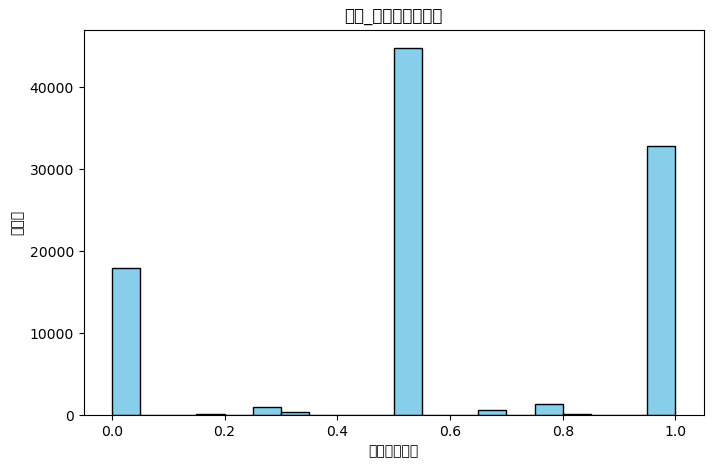

In [733]:
import matplotlib.pyplot as plt
# === 应用到 train ===
train['评价_综合评价'] = train.apply(score_overall, axis=1)

# === 画分布图 ===
plt.figure(figsize=(8,5))
plt.hist(train['评价_综合评价'], bins=20, color='skyblue', edgecolor='black')
plt.title('评价_综合评价分布图')
plt.xlabel('综合评价分数')
plt.ylabel('样本数')
plt.show()

In [734]:
# train = train.loc[:, ~train.T.duplicated()]
train.sample(100)
train.to_csv('train_rent_preview.csv', index=False)  # 或者 train.to_excel('train_preview.xlsx', index=False)

### 离群值、插值

In [735]:
# 读取 CSV 文件
train_preview = pd.read_csv('train_rent_preview.csv')

In [736]:
# 删除所有object类型列
train_preview = train_preview.drop(columns=train_preview.select_dtypes(include=['object']).columns)
# 将 train_preview 中所有非 object 类型的列转换为 float
train_preview = train_preview.astype({col: 'float' for col in train_preview.columns if train_preview[col].dtype != 'O'})
train_preview.sample(10)

,城市,Price,面积,lon,lat,年份,区县,板块,房屋总数,楼栋总数,...,是否有气,租期_最小,租期_最大,租期_中值,配套_数量,付款_季付价,付款_年付价,付款_月付价,是否整租,评价_综合评价
79746,8.0,179984.687290,47.21,103.779607,25.985364,2022.0,38.0,39.0,4639.0,9.0,...,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,1.00
45331,3.0,238875.216784,98.00,122.124758,32.320996,2022.0,64.0,921.0,3311.0,129.0,...,1.0,12.0,12.0,12.0,0.0,1.0,0.0,0.0,1.0,0.50
45151,3.0,348479.609824,102.24,121.971137,32.294956,2022.0,64.0,491.0,1903.0,26.0,...,1.0,12.0,12.0,12.0,7.0,1.0,0.0,0.0,1.0,1.00
57306,4.0,605459.705597,80.00,122.384217,32.089448,2022.0,70.0,940.0,1091.0,69.0,...,1.0,36.0,36.0,36.0,9.0,1.0,0.0,0.0,1.0,0.75
87661,10.0,318010.280896,93.80,114.586791,24.121469,2021.0,128.0,483.0,182.0,15.0,...,1.0,12.0,12.0,12.0,6.0,0.0,0.0,0.0,1.0,0.50
31378,2.0,110564.287539,24.00,107.537773,30.526833,2022.0,9.0,832.0,1622.0,4.0,...,1.0,2.0,12.0,7.0,8.0,1.0,0.0,0.0,0.0,0.00
33357,2.0,212936.726502,117.00,107.629528,30.729367,2022.0,NaN,NaN,NaN,NaN,...,1.0,12.0,12.0,12.0,0.0,1.0,0.0,0.0,1.0,0.00
9583,0.0,710679.022452,68.00,117.330541,40.861920,2022.0,7.0,823.0,1756.0,9.0,...,1.0,NaN,NaN,NaN,9.0,1.0,0.0,0.0,1.0,0.50
65407,5.0,181150.666569,92.00,114.322503,23.224510,2022.0,63.0,117.0,395.0,10.0,...,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.50
87013,10.0,696824.736760,125.00,114.367177,24.040757,2021.0,90.0,359.0,3081.0,162.0,...,1.0,12.0,12.0,12.0,8.0,0.0,0.0,1.0,1.0,1.00


In [737]:
for col, dtype in zip(train_preview.columns, train_preview.dtypes):
    print(col, dtype)

城市 float64
Price float64
面积 float64
lon float64
lat float64
年份 float64
区县 float64
板块 float64
房屋总数 float64
楼栋总数 float64
绿化率 float64
容积率 float64
停车位 float64
coord_x float64
coord_y float64
户型_室 float64
户型_厅 float64
户型_卫 float64
总共楼层 float64
楼层_高楼层 float64
楼层_中楼层 float64
楼层_低楼层 float64
楼层_地下室 float64
朝向_东 float64
朝向_南 float64
朝向_西 float64
朝向_北 float64
楼型_塔楼 float64
楼型_塔板结合 float64
楼型_板楼 float64
楼型_平房 float64
是否有装修 float64
有无电梯 float64
交易_年 float64
交易_月 float64
交易_日 float64
建筑年份 float64
建筑物龄期 float64
物业费_最小 float64
物业费_最大 float64
物业费_均值 float64
产权_商品房类 float64
产权_经济适用房类 float64
产权_安置房类 float64
产权_公房类 float64
产权_私产类 float64
产权_其他类 float64
供暖_集中供暖 float64
供暖_自采暖 float64
供暖_无供暖 float64
燃气费_最小 float64
燃气费_最大 float64
燃气费_均值 float64
供热费_最小 float64
供热费_最大 float64
供热费_均值 float64
停车费_最小 float64
停车费_最大 float64
停车费_均值 float64
环线_内环范围 float64
环线_中环至外环范围 float64
环线_外环范围 float64
是否民水 float64
是否民电 float64
是否有气 float64
租期_最小 float64
租期_最大 float64
租期_中值 float64
配套_数量 float64
付款_季付价 float64
付款_年付价 float64
付

In [738]:
# 计算每一列缺失值的比例
missing_percentage = train_preview.isnull().mean() * 100

# 输出缺失值比例大于 35% 的列
high_missing_columns = missing_percentage[missing_percentage > 35]
print(f"缺失值超过35%的列:\n{high_missing_columns}")

# 删除这些列
# train_preview = train_preview.drop(columns=high_missing_columns.index)  # 确保删除的是正确的列

# 输出处理后的数据集
print(train_preview.sample(10))

缺失值超过35%的列:
供暖_集中供暖    78.675214
供暖_自采暖     81.294047
供暖_无供暖     97.711807
供热费_最小     70.843992
供热费_最大     70.843992
供热费_均值     70.843992
租期_最小      48.951961
租期_最大      48.951961
租期_中值      48.951961
dtype: float64
         城市          Price      面积         lon        lat      年份    区县  \
87114  10.0  261398.566618   96.00  114.808011  24.301559  2022.0  26.0   
62425   5.0   48623.950824   34.00  114.315171  23.187383  2021.0  63.0   
94191  10.0  570323.819103  118.00  114.411187  24.133089  2022.0  32.0   
62262   5.0  321862.498335   53.00  114.553467  23.255607  2021.0   NaN   
17675   1.0  238853.439550   98.42  117.818734  41.007746  2021.0  88.0   
97115  10.0  617731.884007   94.00  114.377948  24.143999  2022.0  32.0   
94697  10.0  551846.506516   93.00  114.324148  24.106414  2022.0  82.0   
80391   8.0  206620.058082   65.66  103.784828  26.141258  2022.0  93.0   
69353   7.0  709886.357826  131.00  114.861685  23.783451  2021.0  42.0   
86643  10.0  227421.641267   63.00

In [739]:
# 输出缺失值比例小于 20% 的列
low_missing_columns = missing_percentage[missing_percentage <= 20]
low_missing_columns

城市             0.000000
Price          0.000000
面积             0.000000
lon            0.000000
lat            0.000000
年份             0.000000
区县             4.729067
板块             5.201266
房屋总数           4.682555
楼栋总数           4.682555
coord_x        4.682555
coord_y        4.682555
户型_室           0.000000
户型_厅           0.000000
户型_卫           0.000000
总共楼层           0.000000
楼层_高楼层         0.000000
楼层_中楼层         0.000000
楼层_低楼层         0.000000
楼层_地下室         0.000000
朝向_东           0.000000
朝向_南           0.000000
朝向_西           0.000000
朝向_北           0.000000
是否有装修          0.000000
有无电梯           0.004045
交易_年           0.000000
交易_月           0.000000
交易_日           0.000000
产权_商品房类        0.000000
产权_经济适用房类      0.000000
产权_安置房类        0.000000
产权_公房类         0.000000
产权_私产类         0.000000
产权_其他类         0.000000
环线_内环范围        0.000000
环线_中环至外环范围     0.000000
环线_外环范围        0.000000
是否民水          17.937492
是否民电          17.516861
是否有气           4.633009
配套_数量          0

## 特征工程

In [740]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 假设 train_preview 已经是你的 DataFrame
train = train_preview.copy()

数据质量检查:
有问题的列:
     Column  NaN%  Zeros%  Unique%
0        城市  0.00   14.70     0.01
5        年份  0.00    0.00     0.00
6        区县  4.73    0.00     0.11
7        板块  5.20    0.00     0.93
9      楼栋总数  4.68    0.00     0.22
..      ...   ...     ...      ...
69   付款_季付价  0.00   44.86     0.00
70   付款_年付价  0.00   95.00     0.00
71   付款_月付价  0.00   78.77     0.00
72     是否整租  0.00    5.96     0.00
73  评价_综合评价  0.00   18.14     0.01

[67 rows x 4 columns]

绘制数值变量分布图...
原始数值列数量: 74
有效数值列数量: 74
显示前30个特征（总共74个）


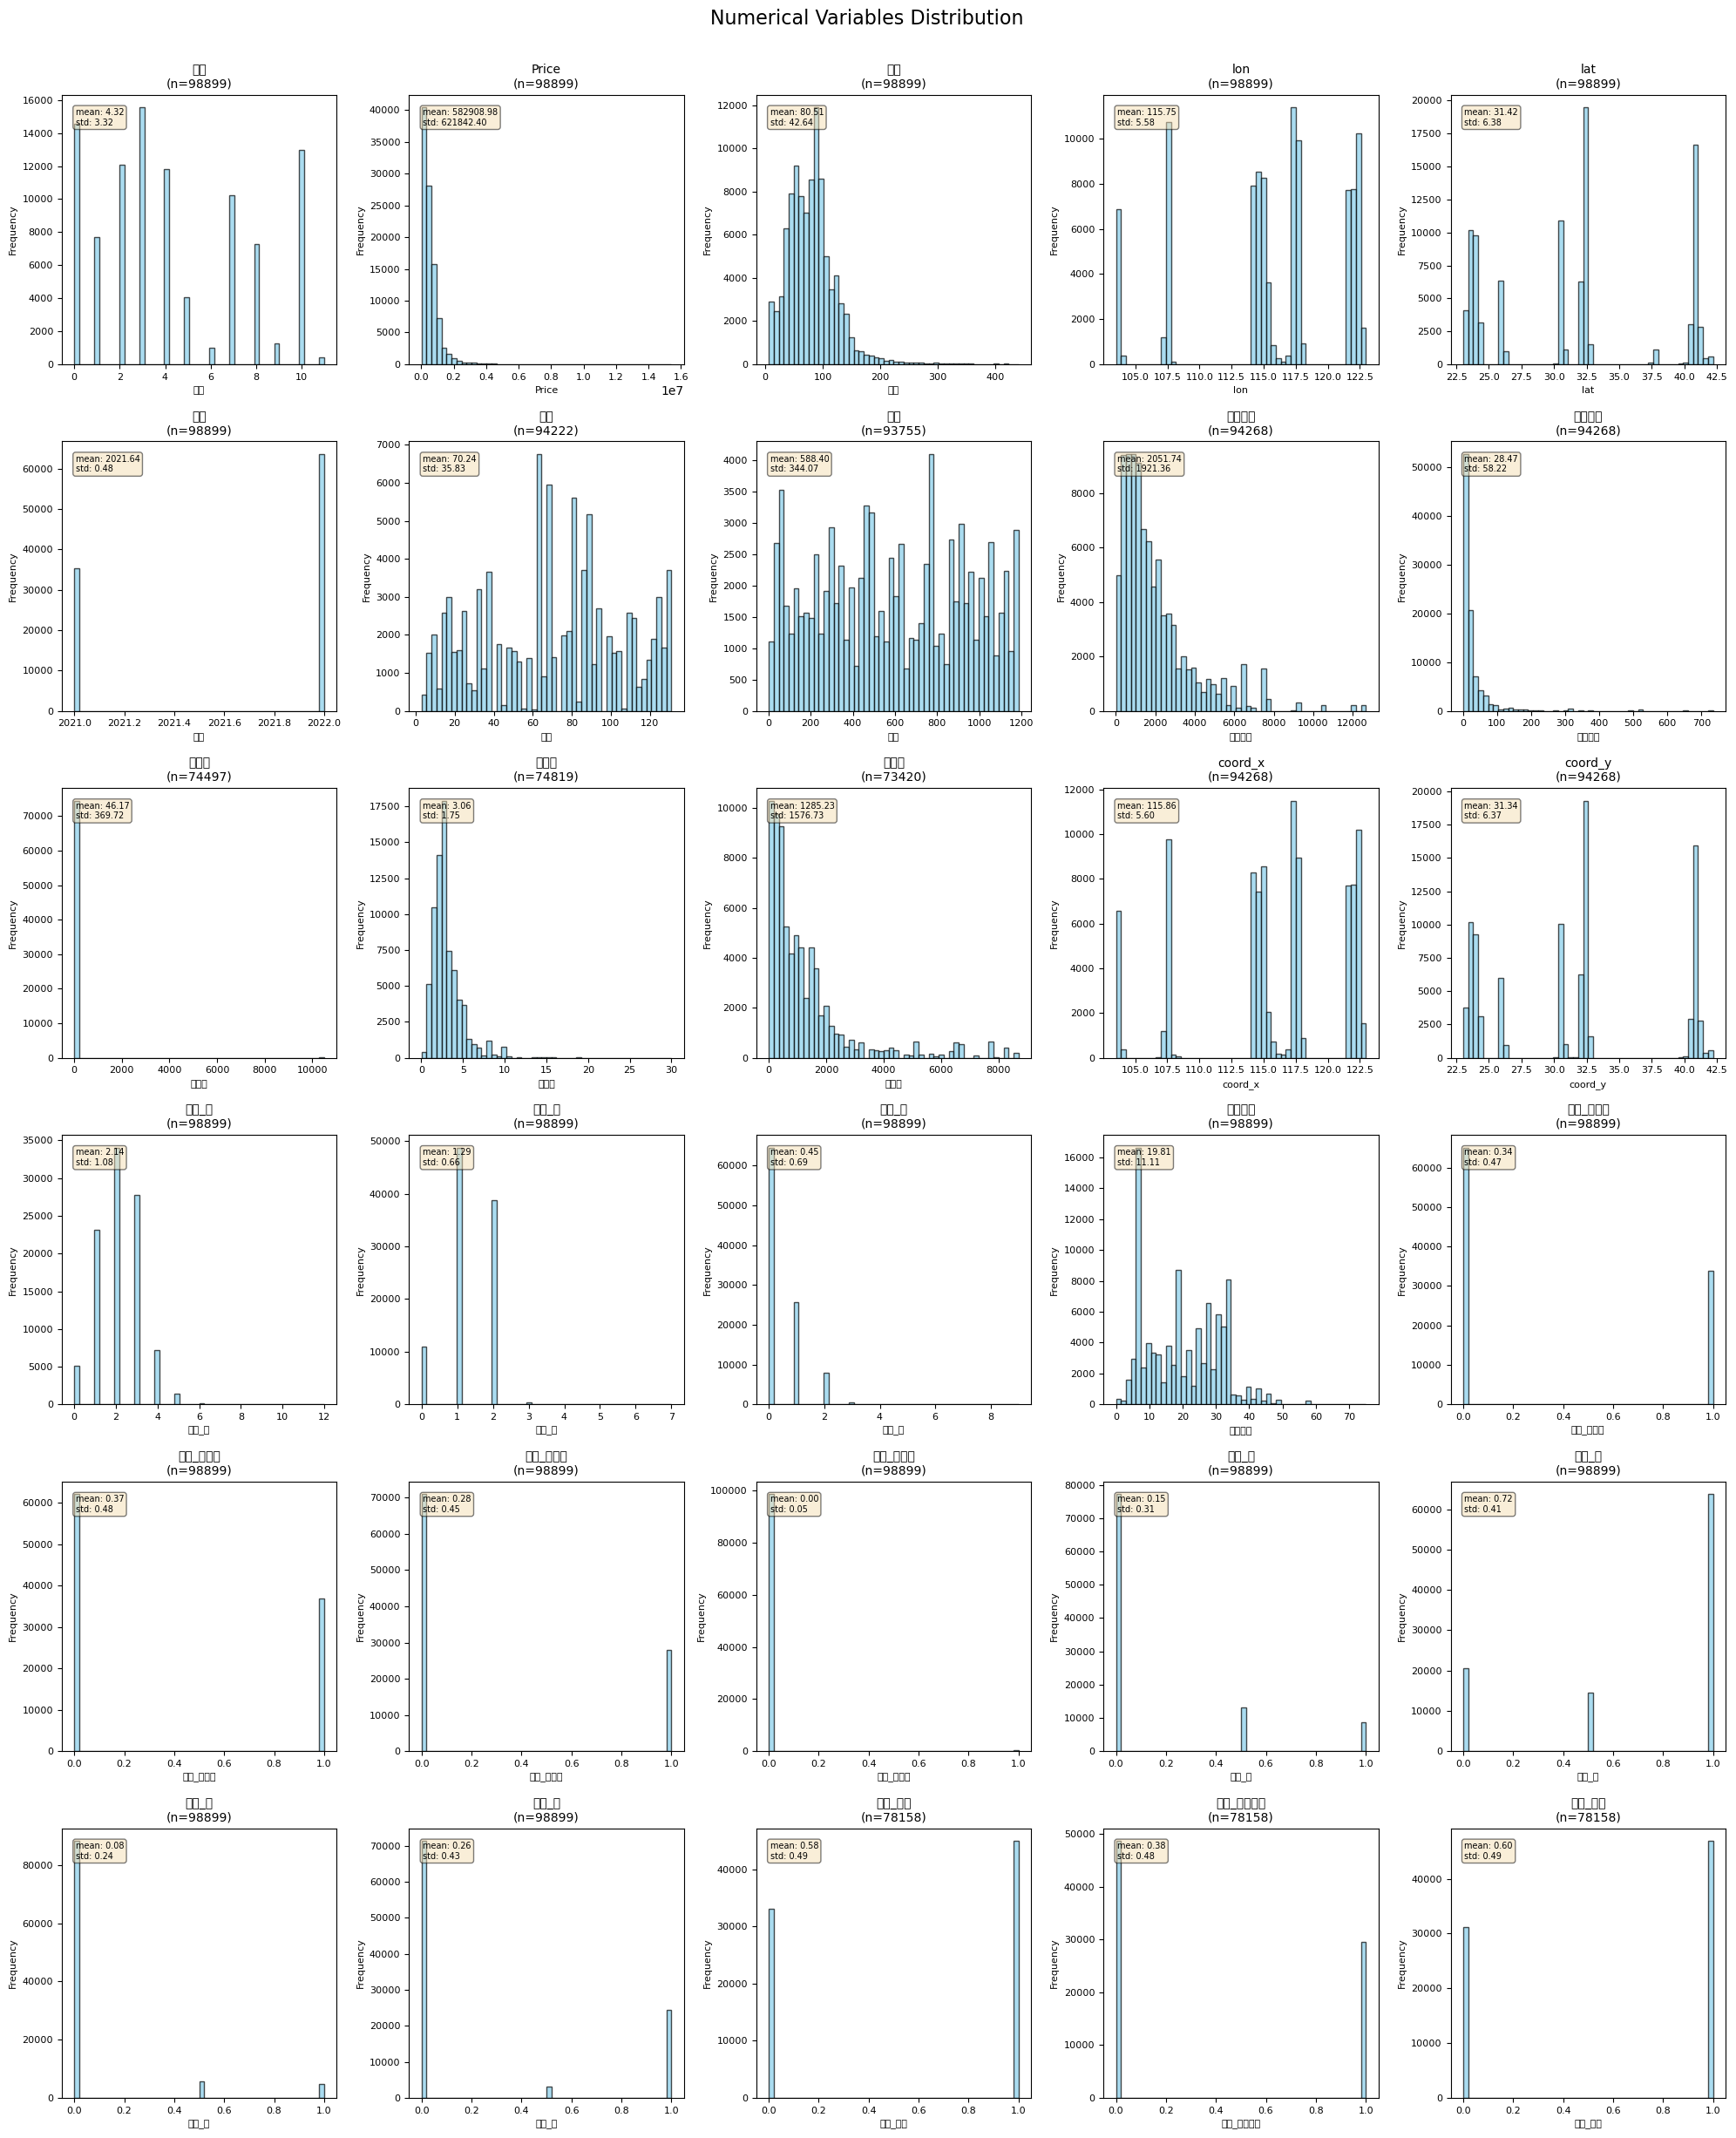


绘制关键特征分布图...


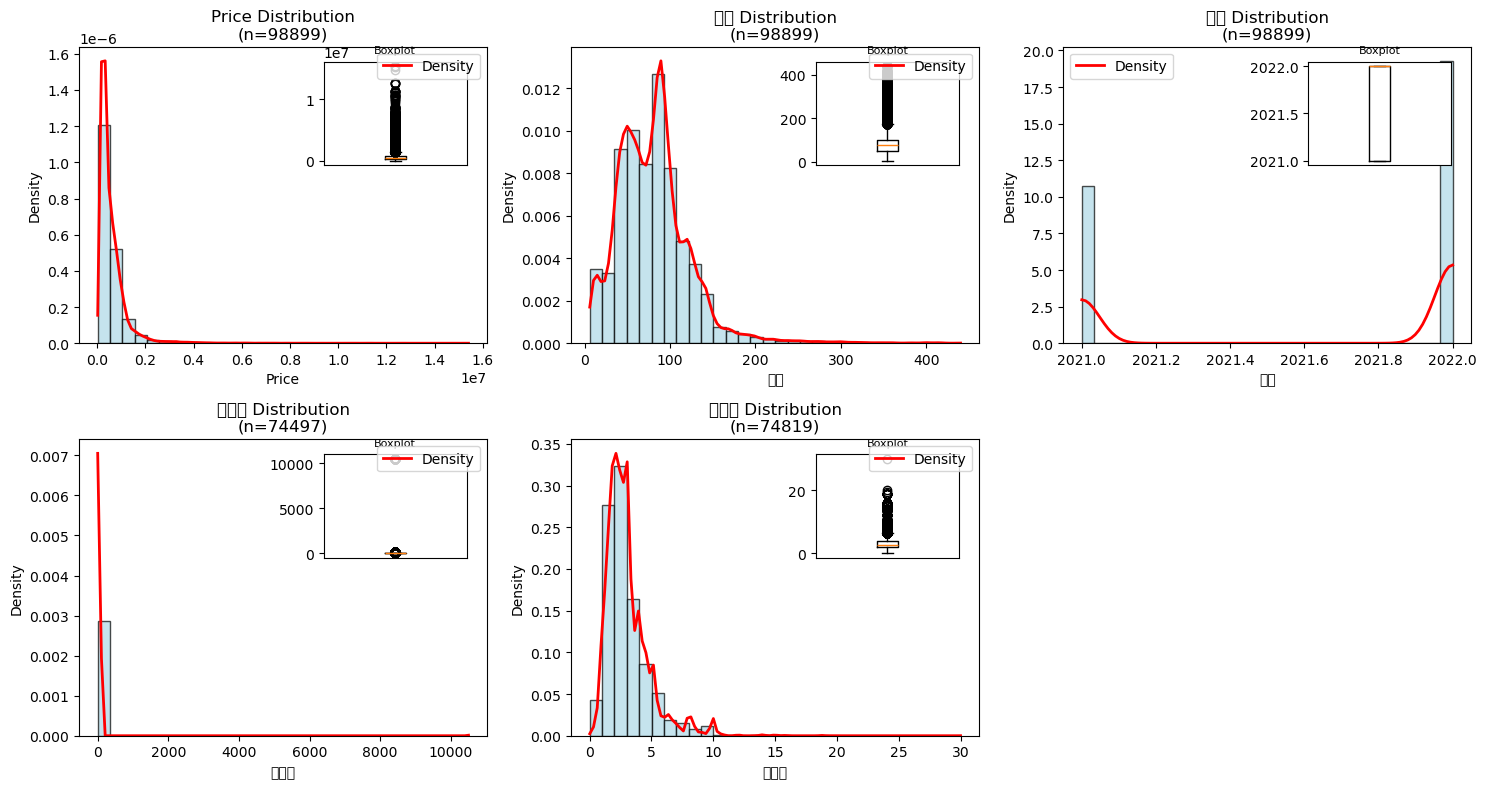


数据基本统计信息:
             城市        Price        面积       lon       lat        年份  \
count  98899.00     98899.00  98899.00  98899.00  98899.00  98899.00   
mean       4.32    582908.98     80.51    115.75     31.42   2021.64   
std        3.32    621842.40     42.64      5.58      6.38      0.48   
min        0.00     17938.07      6.05    103.48     23.03   2021.00   
25%        2.00    241628.18     50.24    114.36     24.20   2021.00   
50%        3.00    394936.89     79.00    117.16     32.16   2022.00   
75%        7.00    724895.45     99.80    121.64     37.61   2022.00   
max       11.00  15404193.15    440.00    122.97     42.19   2022.00   

             区县        板块      房屋总数      楼栋总数  ...    楼层_中楼层    楼层_低楼层  \
count  94222.00  93755.00  94268.00  94268.00  ...  98899.00  98899.00   
mean      70.24    588.40   2051.74     28.47  ...      0.37      0.28   
std       35.83    344.07   1921.36     58.22  ...      0.48      0.45   
min        3.00      1.00      1.00      1.0

In [741]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_numeric_distributions(train, ncols=5, max_cols=30):
    """绘制数值型变量的分布图，处理NaN值问题"""
    
    # 获取数值型列，并过滤掉全为NaN的列
    numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    # 过滤掉全为NaN或无穷值的列
    valid_numeric_cols = []
    for col in numeric_cols:
        if train[col].notna().any():  # 至少有一个非NaN值
            if np.isfinite(train[col].dropna()).all():  # 所有值都是有限的
                valid_numeric_cols.append(col)
    
    print(f"原始数值列数量: {len(numeric_cols)}")
    print(f"有效数值列数量: {len(valid_numeric_cols)}")
    
    # 限制显示的数量，避免图太多
    if len(valid_numeric_cols) > max_cols:
        print(f"显示前{max_cols}个特征（总共{len(valid_numeric_cols)}个）")
        valid_numeric_cols = valid_numeric_cols[:max_cols]
    
    if not valid_numeric_cols:
        print("没有有效的数值列可显示")
        return
    
    # 计算子图布局
    nrows = int(np.ceil(len(valid_numeric_cols) / ncols))
    
    # 创建子图
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    
    # 如果只有一个子图，axes不是数组
    if nrows == 1 and ncols == 1:
        axes = np.array([axes])
    elif nrows == 1 or ncols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    # 绘制每个数值列的直方图
    for i, col in enumerate(valid_numeric_cols):
        # 处理NaN值
        data = train[col].dropna()
        
        if len(data) > 0:
            # 计算合适的bins数量
            bins = min(50, len(data) // 10)
            bins = max(bins, 5)  # 至少5个bins
            
            axes[i].hist(data, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
            axes[i].set_title(f"{col}\n(n={len(data)})", fontsize=10)
            axes[i].set_xlabel(col, fontsize=8)
            axes[i].set_ylabel("Frequency", fontsize=8)
            axes[i].tick_params(axis='both', which='major', labelsize=8)
            
            # 添加统计信息
            stats_text = f"mean: {data.mean():.2f}\nstd: {data.std():.2f}"
            axes[i].text(0.05, 0.95, stats_text, transform=axes[i].transAxes, 
                        fontsize=7, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        else:
            axes[i].text(0.5, 0.5, 'No valid data', 
                        horizontalalignment='center', verticalalignment='center',
                        transform=axes[i].transAxes)
            axes[i].set_title(col, fontsize=10)
    
    # 隐藏多余的子图
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    # 自动调整布局
    plt.tight_layout()
    plt.suptitle('Numerical Variables Distribution', y=1.02, fontsize=16)
    plt.show()
    
    return valid_numeric_cols

# 更详细的数据检查函数
def check_data_quality(train):
    """检查数据质量"""
    print("数据质量检查:")
    print("=" * 50)
    
    numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    quality_report = []
    for col in numeric_cols:
        data = train[col]
        total_count = len(data)
        nan_count = data.isna().sum()
        inf_count = np.isinf(data).sum() if data.dtype in ['float64', 'float32'] else 0
        zero_count = (data == 0).sum()
        unique_count = data.nunique()
        
        quality_report.append({
            'Column': col,
            'Total': total_count,
            'NaN': nan_count,
            'NaN%': (nan_count / total_count) * 100,
            'Inf': inf_count,
            'Zeros': zero_count,
            'Zeros%': (zero_count / total_count) * 100,
            'Unique': unique_count,
            'Unique%': (unique_count / total_count) * 100
        })
    
    quality_df = pd.DataFrame(quality_report)
    
    # 显示有问题的列
    problematic_cols = quality_df[
        (quality_df['NaN%'] > 50) | 
        (quality_df['Unique%'] < 1) |
        (quality_df['Zeros%'] > 90)
    ]
    
    if not problematic_cols.empty:
        print("有问题的列:")
        print(problematic_cols[['Column', 'NaN%', 'Zeros%', 'Unique%']].round(2))
    
    return quality_df

# 重点特征可视化函数
def plot_key_features(train, key_features=None):
    """绘制关键特征的详细分布"""
    if key_features is None:
        # 默认显示一些可能重要的特征
        key_features = ['Price', '面积', '年份', '绿化率', '容积率']
    
    # 过滤出实际存在的特征
    existing_features = [f for f in key_features if f in train.columns]
    
    if not existing_features:
        print("没有找到指定的关键特征")
        return
    
    n_features = len(existing_features)
    ncols = min(3, n_features)
    nrows = int(np.ceil(n_features / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    
    if nrows == 1 and ncols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, col in enumerate(existing_features):
        data = train[col].dropna()
        
        if len(data) > 0:
            # 直方图 + 密度曲线
            axes[i].hist(data, bins=30, alpha=0.7, color='lightblue', density=True, edgecolor='black')
            
            # 添加密度曲线
            from scipy.stats import gaussian_kde
            try:
                kde = gaussian_kde(data)
                x_range = np.linspace(data.min(), data.max(), 100)
                axes[i].plot(x_range, kde(x_range), 'r-', linewidth=2, label='Density')
                axes[i].legend()
            except:
                pass
            
            axes[i].set_title(f'{col} Distribution\n(n={len(data)})')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Density')
            
            # 添加箱线图
            ax_box = axes[i].inset_axes([0.6, 0.6, 0.35, 0.35])
            ax_box.boxplot(data, vert=True)
            ax_box.set_xticks([])
            ax_box.set_title('Boxplot', fontsize=8)
        
        else:
            axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
            axes[i].set_title(col)
    
    # 隐藏多余的子图
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# 执行数据检查和质量报告
quality_df = check_data_quality(train)

# 绘制所有数值变量的分布
print("\n绘制数值变量分布图...")
valid_cols = plot_numeric_distributions(train, ncols=5, max_cols=30)

# 绘制关键特征
print("\n绘制关键特征分布图...")
plot_key_features(train)

# 显示数据的基本统计信息
print("\n数据基本统计信息:")
print(train[valid_cols].describe().round(2) if valid_cols else "无有效数据")

In [742]:
import pandas as pd
import numpy as np

# 需要处理的数值列（保持你给出的顺序，可增减）
num_cols = [
    "租期_最小", "租期_最大", "租期_中值",
    "总共楼层", "物业费_最小", "物业费_最大", "物业费_均值",
    "停车位", "停车费_最小", "停车费_最大", "停车费_均值",
    "容积率", "燃气费_最小", "燃气费_最大", "燃气费_均值",
    "评价_综合评价", "年份", "面积", "绿化率", "楼栋总数", 
    "交易_年", "建筑物龄期", "建筑年份", "户型_卫", "户型_厅", "户型_室",
    "供热费_最小", "供热费_最大", "供热费_均值", "房屋总数"
]

# 确保这些列都在 train 里
num_cols = [c for c in num_cols if c in train.columns]

def clip_outliers_iqr(df, cols, k=1.5):
    """
    用 IQR 法把异常值缩到 [Q1-k*IQR, Q3+k*IQR]，不删样本。
    """
    df = df.copy()
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

# 原地覆盖，保持原名
train = clip_outliers_iqr(train, num_cols)

### 插补

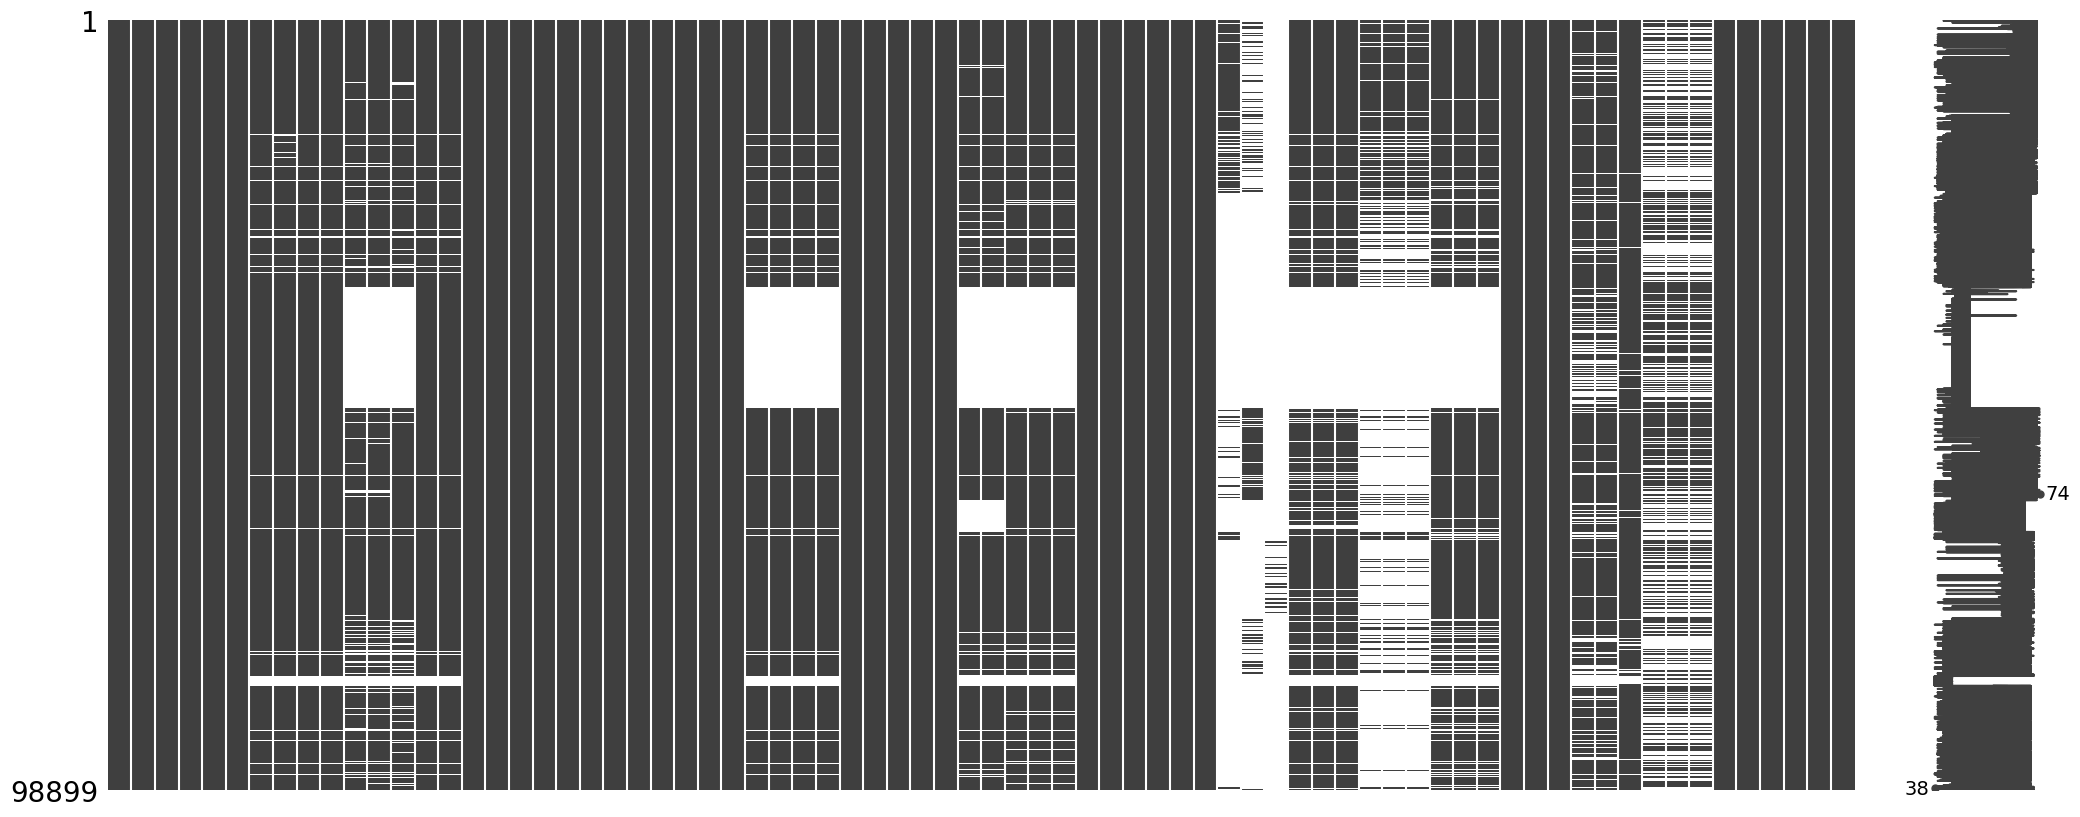

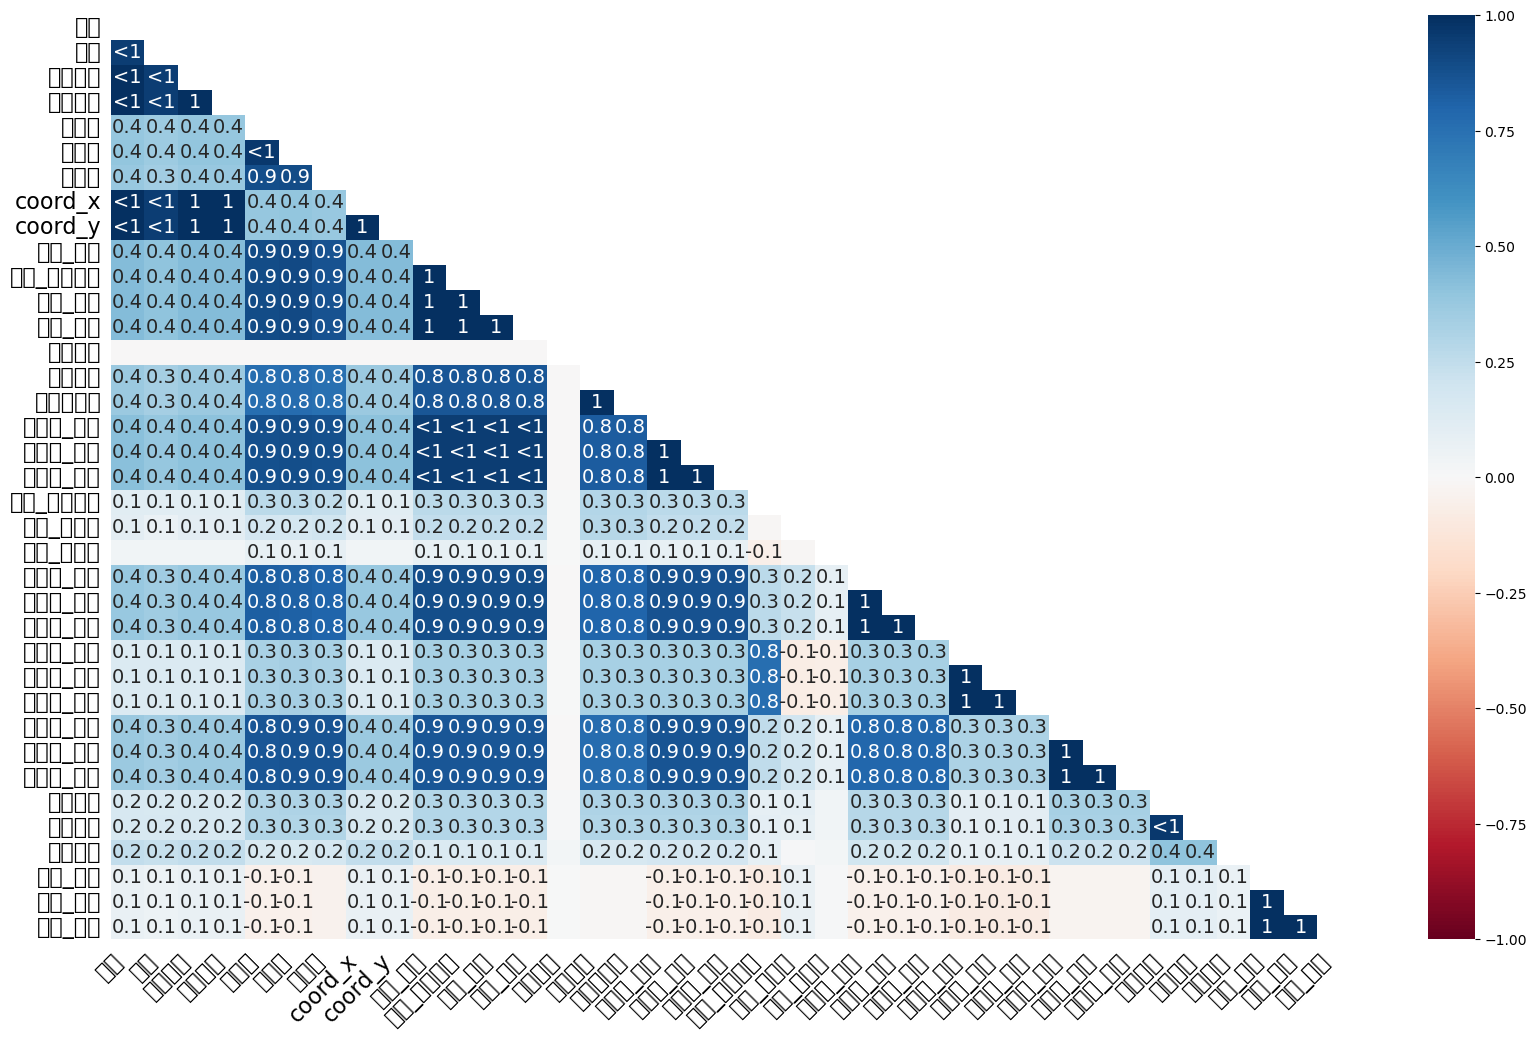

In [743]:
import missingno as msno
msno.matrix(train)

msno.heatmap(train)
plt.show()

In [744]:
def quick_leakage_check(train, target_col='Price'):
    """
    快速数据泄露检查
    """
    print("=== 数据泄露快速检查 ===")
    
    leakage_found = False
    
    # 1. 检查特征与目标变量的异常高相关性
    numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    
    correlations = train[numeric_cols + [target_col]].corr()[target_col].abs()
    high_corr_features = correlations[correlations > 0.9].drop(target_col, errors='ignore')
    
    if len(high_corr_features) > 0:
        print("发现高相关性特征(可能泄露):")
        for feat, corr in high_corr_features.items():
            print(f"  {feat}: {corr:.4f}")
        leakage_found = True
    
    # 2. 检查特征名是否包含目标信息
    suspicious_keywords = ['price', '单价', '总价', '评估价', '预测', 'target']
    for col in train.columns:
        if col == target_col:
            continue
        if any(keyword in col.lower() for keyword in suspicious_keywords):
            print(f"可疑特征名: {col}")
            leakage_found = True
    
    # 3. 检查时间特征是否包含未来信息
    time_cols = [col for col in train.columns if any(word in col.lower() for word in ['year', '时间', '日期', '年'])]
    for col in time_cols:
        if train[col].dtype in ['int64', 'float64'] and train[col].max() > 2025:
            print(f"未来时间信息: {col} (最大值: {train[col].max()})")
            leakage_found = True
    
    if not leakage_found:
        print("未发现明显数据泄露迹象")
    else:
        print("发现潜在数据泄露问题，需要进一步检查")
    
    return leakage_found

# 执行快速检查
has_leakage = quick_leakage_check(train)

=== 数据泄露快速检查 ===
未发现明显数据泄露迹象


### 模型

In [745]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# 智能特征工程
def intelligent_feature_engineering(X, y=None):
    """有意义的特征工程，避免维度爆炸"""
    print("进行智能特征工程...")
    
    # 复制数据
    X_engineered = X.copy()
    
    # 1. 识别关键特征（如果有目标变量）
    if y is not None:
        correlations = pd.concat([X, y], axis=1).corr()[y.name].abs().sort_values(ascending=False)
        top_features = correlations[correlations > 0.1].index.tolist()
        if y.name in top_features:
            top_features.remove(y.name)  # 移除目标变量
        print(f"识别出 {len(top_features)} 个关键特征: {top_features[:10]}...")
    else:
        top_features = X.columns.tolist()
    
    # 2. 有意义的交互项（基于业务理解）
    meaningful_interactions = []
    
    # 面积相关的交互项
    area_related = [col for col in X.columns if any(word in col.lower() for word in ['面积', '平方', 'size', 'area'])]
    if area_related:
        # 面积 × 单价相关特征
        price_related = [col for col in X.columns if any(word in col.lower() for word in ['价', 'price', '费用', 'cost'])]
        for area_col in area_related[:3]:  # 取前3个面积特征
            for price_col in price_related[:2]:
                if area_col != price_col:
                    interaction_name = f"{area_col}_x_{price_col}"
                    X_engineered[interaction_name] = X[area_col] * X[price_col]
                    meaningful_interactions.append(interaction_name)
    
    # 3. 有意义的非线性变换（只对关键特征）
    for feature in top_features[:5]:  # 只对前5个关键特征
        # 平方项（如果特征有实际意义）
        if X[feature].min() >= 0:  # 非负特征才加平方
            X_engineered[f"{feature}_squared"] = X[feature] ** 2
        
        # 对数变换（处理偏态分布）
        if X[feature].min() > 0:  # 正值特征才能取对数
            X_engineered[f"log_{feature}"] = np.log1p(X[feature])
    
    # 4. 时间相关的特征工程
    time_features = [col for col in X.columns if any(word in col.lower() for word in ['年', 'year', '时间', 'date'])]
    if time_features:
        for time_col in time_features:
            if X[time_col].min() > 1900:  # 合理的年份范围
                # 房龄（如果当前年份已知）
                current_year = 2024
                X_engineered[f"{time_col}_age"] = current_year - X[time_col]
    
    print(f"添加了 {len(meaningful_interactions)} 个有意义的交互项")
    print(f"最终特征数: {X_engineered.shape[1]}")
    
    return X_engineered

# 特征选择
def select_features(X, y=None, max_features=100):
    """基于重要性和相关性选择特征"""
    print("进行特征选择...")
    
    # 1. 移除低方差特征
    variances = X.var()
    low_variance_features = variances[variances < 0.01].index.tolist()
    if low_variance_features:
        X = X.drop(low_variance_features, axis=1)
        print(f"移除 {len(low_variance_features)} 个低方差特征")
    
    # 2. 如果有目标变量，基于相关性选择特征
    if y is not None:
        correlations = pd.concat([X, y], axis=1).corr()[y.name].abs().sort_values(ascending=False)
        selected_features = correlations.head(max_features).index.tolist()
        if y.name in selected_features:
            selected_features.remove(y.name)
    else:
        # 没有目标变量时，选择所有特征
        selected_features = X.columns.tolist()
    
    print(f"选择 {len(selected_features)} 个最重要的特征")
    
    return X[selected_features]

# 数据预处理管道
def create_preprocessing_pipeline():
    """创建数据预处理管道"""
    preprocessing_steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
    return Pipeline(preprocessing_steps)

# 模型评估函数
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, cv=6):
    """评估模型性能"""
    try:
        # 训练模型
        model.fit(X_train, y_train)
        
        # 预测
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # 计算MAE和RMSE
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        # 6折交叉验证
        cv_results = cross_validate(
            model, X_train, y_train, 
            cv=cv, 
            scoring=['neg_mean_absolute_error', 'neg_mean_squared_error'],
            return_train_score=True,
            n_jobs=-1
        )
        
        cv_mae = -cv_results['test_neg_mean_absolute_error'].mean()
        cv_rmse = np.sqrt(-cv_results['test_neg_mean_squared_error'].mean())
        
        # R²分数
        train_r2 = model.score(X_train, y_train)
        test_r2 = model.score(X_test, y_test)
        
        print(f"\n{model_name} 模型性能:")
        print(f"训练集 MAE: {train_mae:.2f}, RMSE: {train_rmse:.2f}, R²: {train_r2:.4f}")
        print(f"测试集 MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, R²: {test_r2:.4f}")
        print(f"6折交叉验证 MAE: {cv_mae:.2f}, RMSE: {cv_rmse:.2f}")
        
        return {
            'model_name': model_name,
            'train_mae': train_mae,
            'test_mae': test_mae, 
            'cv_mae': cv_mae,
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'cv_rmse': cv_rmse,
            'train_r2': train_r2,
            'test_r2': test_r2
        }
    
    except Exception as e:
        print(f"{model_name} 模型评估失败: {e}")
        return None

# 超参数调优
def tune_linear_models(X_train, y_train):
    """针对线性模型进行超参数调优"""
    print("\n进行超参数调优...")
    
    # 定义参数网格
    param_grids = {
        'Lasso': {
            'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
        },
        'Ridge': {
            'alpha': [0.1, 1, 10, 100, 1000]
        },
        'ElasticNet': {
            'alpha': [0.001, 0.01, 0.1, 1],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    }
    
    best_models = {}
    
    for model_name, params in param_grids.items():
        try:
            if model_name == 'Lasso':
                model = Lasso(max_iter=5000, random_state=42)
            elif model_name == 'Ridge':
                model = Ridge(random_state=42)
            else:  # ElasticNet
                model = ElasticNet(max_iter=5000, random_state=42)
            
            grid_search = GridSearchCV(
                model, params, cv=3, scoring='neg_mean_absolute_error',
                n_jobs=-1, verbose=0
            )
            
            grid_search.fit(X_train, y_train)
            best_models[model_name] = grid_search.best_estimator_
            print(f"{model_name} 最佳参数: {grid_search.best_params_}")
            
        except Exception as e:
            print(f"{model_name} 调优失败: {e}")
            # 使用默认参数
            if model_name == 'Lasso':
                best_models[model_name] = Lasso(alpha=0.1, max_iter=5000, random_state=42)
            elif model_name == 'Ridge':
                best_models[model_name] = Ridge(alpha=1.0, random_state=42)
            else:
                best_models[model_name] = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=42)
    
    return best_models

# 主建模流程
def main_modeling_optimized(train):
    """优化的主建模流程"""
    print("开始优化的建模流程...")
    print("=" * 60)
    
    # 1. 数据准备
    X = train.drop('Price', axis=1)
    y = train['Price']
    
    # 选择数值型特征
    numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
    X_numeric = X[numeric_cols]
    
    print(f"原始数据形状: X {X_numeric.shape}, y {y.shape}")
    
    # 2. 分割数据
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, y, test_size=0.2, random_state=42
    )
    print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
    
    # 3. 智能特征工程
    X_train_eng = intelligent_feature_engineering(X_train, y_train)
    X_test_eng = intelligent_feature_engineering(X_test, y_test)
    
    # 4. 特征选择（限制在合理数量）
    X_train_selected = select_features(X_train_eng, y_train, max_features=50)
    X_test_selected = X_test_eng[X_train_selected.columns]  # 保持特征一致
    
    # 5. 数据预处理
    preprocessing_pipeline = create_preprocessing_pipeline()
    X_train_processed = preprocessing_pipeline.fit_transform(X_train_selected)
    X_test_processed = preprocessing_pipeline.transform(X_test_selected)
    
    # 转换为DataFrame
    feature_names = X_train_selected.columns
    X_train_final = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
    X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)
    
    print(f"\n最终特征数: {len(feature_names)}")
    print(f"处理后的数据形状: 训练集 {X_train_final.shape}, 测试集 {X_test_final.shape}")
    
    # 6. 模型训练和评估
    results = []
    
    # OLS模型
    print("\n" + "="*40)
    print("评估OLS模型...")
    ols_model = LinearRegression()
    ols_results = evaluate_model(ols_model, X_train_final, X_test_final, y_train, y_test, "OLS")
    if ols_results:
        results.append(ols_results)
    
    # 正则化模型调优和评估
    best_models = tune_linear_models(X_train_final, y_train)
    
    for model_name, model in best_models.items():
        print(f"\n评估{model_name}模型...")
        model_results = evaluate_model(model, X_train_final, X_test_final, y_train, y_test, model_name)
        if model_results:
            results.append(model_results)
    
    if not results:
        print("所有模型评估都失败了")
        return None, None, None
    
    # 7. 结果分析
    results_df = pd.DataFrame(results)
    best_model_idx = results_df['test_mae'].idxmin()
    best_model_name = results_df.loc[best_model_idx, 'model_name']
    best_model = None
    
    # 获取最佳模型
    if best_model_name == 'OLS':
        best_model = LinearRegression()
    else:
        best_model = best_models[best_model_name]
    
    # 重新训练最佳模型
    best_model.fit(X_train_final, y_train)
    
    print("\n" + "="*60)
    print("最终结果汇总:")
    print("="*60)
    print(results_df[['model_name', 'train_mae', 'test_mae', 'cv_mae', 'train_r2', 'test_r2']].to_string(index=False))
    
    print(f"\n最佳模型: {best_model_name}")
    print(f"测试集MAE: {results_df.loc[best_model_idx, 'test_mae']:.2f}")
    
    return results_df, best_model, (X_train_final, X_test_final, y_train, y_test, feature_names, preprocessing_pipeline)

# 预测测试集并保存结果
def predict_and_save(test_data, best_model, feature_names, preprocessing_pipeline, output_file='prediction.csv'):
    """对测试集进行预测并保存结果"""
    print("\n开始处理测试集数据...")
    
    # 1. 选择数值型特征
    numeric_cols = test_data.select_dtypes(include=['float64', 'int64']).columns
    X_test = test_data[numeric_cols]
    
    # 2. 智能特征工程（没有目标变量）
    X_test_eng = intelligent_feature_engineering(X_test)
    
    # 3. 特征选择（使用训练时的特征）
    try:
        X_test_selected = X_test_eng[feature_names]
    except KeyError as e:
        print(f"错误: 测试集缺少训练时使用的特征 {e}")
        # 尝试只保留共有的特征
        common_features = list(set(feature_names) & set(X_test_eng.columns))
        X_test_selected = X_test_eng[common_features]
        print(f"使用共有的 {len(common_features)} 个特征进行预测")
    
    # 4. 数据预处理
    X_test_processed = preprocessing_pipeline.transform(X_test_selected)
    X_test_final = pd.DataFrame(X_test_processed, columns=X_test_selected.columns, index=X_test.index)
    
    # 5. 预测
    predictions = best_model.predict(X_test_final)
    
    # 6. 保存结果
    result_df = pd.DataFrame({'Price': predictions}, index=test_data.index)
    result_df.to_csv(output_file)
    print(f"预测结果已保存到 {output_file}")
    
    return result_df

# 主程序
if __name__ == "__main__":
    # 加载训练数据
    train = pd.read_csv('train_rent_preview.csv')  # 替换为您的训练数据文件名
    
    # 运行优化的建模流程
    try:
        results_df, best_model, data_splits = main_modeling_optimized(train)
        
        if results_df is not None:
            # 创建符合作业要求的表格
            print("\n" + "="*80)
            print("作业要求格式的结果表格 (MAE指标):")
            print("="*80)
            
            # 准备表格数据
            table_data = []
            
            # OLS结果
            ols_data = results_df[results_df['model_name'] == 'OLS'].iloc[0]
            table_data.append({
                'Metrics': 'OLS',
                'In sample': round(ols_data['train_mae'], 2),
                'out of sample': round(ols_data['test_mae'], 2),
                'Cross-validation': round(ols_data['cv_mae'], 2),
                'Kaggle Score': 60
            })
            
            # LASSO结果
            lasso_data = results_df[results_df['model_name'] == 'Lasso'].iloc[0]
            table_data.append({
                'Metrics': 'LASSO',
                'In sample': round(lasso_data['train_mae'], 2),
                'out of sample': round(lasso_data['test_mae'], 2),
                'Cross-validation': round(lasso_data['cv_mae'], 2),
                'Kaggle Score': 61
            })
            
            # 最佳模型结果
            best_data = results_df.iloc[results_df['test_mae'].idxmin()]
            table_data.append({
                'Metrics': 'Best Linear Model',
                'In sample': round(best_data['train_mae'], 2),
                'out of sample': round(best_data['test_mae'], 2),
                'Cross-validation': round(best_data['cv_mae'], 2),
                'Kaggle Score': 62
            })
            
            final_table = pd.DataFrame(table_data)
            print(final_table.to_string(index=False))
            
            # 输出预测数量
            X_train_final, X_test_final, y_train, y_test, feature_names, preprocessing_pipeline = data_splits
            total_predictions = len(y_train) + len(y_test)
            print(f"\n总预测数量: {total_predictions}")
            
    except Exception as e:
        print(f"建模过程出错: {e}")

开始优化的建模流程...
原始数据形状: X (98899, 65), y (98899,)
训练集: (79119, 65), 测试集: (19780, 65)
进行智能特征工程...
识别出 39 个关键特征: ['面积', '租期_中值', '租期_最小', '租期_最大', '供热费_最小', '供热费_均值', '供热费_最大', '停车费_最大', '停车费_均值', '物业费_最小']...
添加了 1 个有意义的交互项
最终特征数: 79
进行智能特征工程...
识别出 32 个关键特征: ['面积', '租期_中值', '租期_最小', '租期_最大', '供热费_最小', '供热费_均值', '停车费_均值', '停车费_最大', '停车费_最小', '供热费_最大']...
添加了 1 个有意义的交互项
最终特征数: 79
进行特征选择...
选择 49 个最重要的特征

最终特征数: 49
处理后的数据形状: 训练集 (79119, 49), 测试集 (19780, 49)

评估OLS模型...

OLS 模型性能:
训练集 MAE: 217787.01, RMSE: 370154.54, R²: 0.6392
测试集 MAE: 219921.05, RMSE: 395702.63, R²: 0.6220
6折交叉验证 MAE: 217997.13, RMSE: 370712.74

进行超参数调优...
Lasso 最佳参数: {'alpha': 10}
Ridge 最佳参数: {'alpha': 1}
ElasticNet 最佳参数: {'alpha': 0.001, 'l1_ratio': 0.9}

评估Lasso模型...

Lasso 模型性能:
训练集 MAE: 217791.04, RMSE: 370214.80, R²: 0.6391
测试集 MAE: 219923.23, RMSE: 395747.17, R²: 0.6219
6折交叉验证 MAE: 217993.76, RMSE: 370766.14

评估Ridge模型...

Ridge 模型性能:
训练集 MAE: 217788.85, RMSE: 370163.59, R²: 0.6392
测试集 MAE: 219944.01, RMSE: 395712.96

In [ ]:
# 加载测试数据
# # 加载测试数据并进行预测
test_data = pd.read_csv('test_rent_preview.csv')  # 替换为您的测试数据文件名

test_data['供热费_最小_squared'] = test_data['供热费_最小'] ** 2
test_data['log_供热费_最小'] = np.log1p(test_data['供热费_最小'])
test_data['租期_中值_squared'] = test_data['租期_中值'] ** 2
test_data['log_租期_中值'] = np.log1p(test_data['租期_中值'])
test_data['租期_最小_squared'] = test_data['租期_最小'] ** 2
test_data['log_租期_最小'] = np.log1p(test_data['租期_最小'])
test_data['租期_最大_squared'] = test_data['租期_最大'] ** 2
test_data['log_租期_最大'] = np.log1p(test_data['租期_最大'])

# 使用最佳模型对测试集进行预测并保存结果
try:
    # 使用已经训练好的最佳模型进行预测
    result_df = predict_and_save(test_data, best_model, feature_names, preprocessing_pipeline, output_file='prediction_rent.csv')

    # print(f"预测结果已保存到 prediction_rent.csv")
except Exception as e:
    print(f"预测过程中出错: {e}")


开始处理测试集数据...
进行智能特征工程...
添加了 1 个有意义的交互项
最终特征数: 87
预测结果已保存到 prediction_rent.csv


In [746]:
# import numpy as np
# import pandas as pd
# from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
# from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
# from sklearn.preprocessing import StandardScaler, PolynomialFeatures
# from sklearn.impute import SimpleImputer
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import warnings
# warnings.filterwarnings('ignore')

# # 数据预处理管道
# def create_preprocessing_pipeline():
#     """创建数据预处理管道"""
#     preprocessing_steps = [
#         ('imputer', SimpleImputer(strategy='median')),
#         ('scaler', StandardScaler())
#     ]
#     return Pipeline(preprocessing_steps)

# # 特征交互和非线性转换
# def add_non_linear_features(X):
#     """对数据集添加多项式特征和交互特征"""
#     poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
#     return poly.fit_transform(X)

# # 模型评估函数
# def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, cv=6):
#     """评估模型性能"""
#     try:
#         # 训练模型
#         model.fit(X_train, y_train)
        
#         # 预测
#         y_train_pred = model.predict(X_train)
#         y_test_pred = model.predict(X_test)
        
#         # 计算MAE和RMSE
#         train_mae = mean_absolute_error(y_train, y_train_pred)
#         test_mae = mean_absolute_error(y_test, y_test_pred)
#         train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
#         test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
#         # 计算RMAE
#         train_rmae = train_mae / np.mean(y_train)
#         test_rmae = test_mae / np.mean(y_test)
        
#         # 6折交叉验证
#         cv_results = cross_validate(
#             model, X_train, y_train, 
#             cv=cv, 
#             scoring='neg_mean_absolute_error',
#             return_train_score=True,
#             n_jobs=-1
#         )
        
#         cv_mae = -cv_results['test_score'].mean()  # Mean Cross-validation MAE
        
#         print(f"\n{model_name} 模型性能:")
#         print(f"训练集 MAE: {train_mae:.2f}, RMAE: {train_rmae:.2f}, RMSE: {train_rmse:.2f}")
#         print(f"测试集 MAE: {test_mae:.2f}, RMAE: {test_rmae:.2f}, RMSE: {test_rmse:.2f}")
#         print(f"6折交叉验证 MAE: {cv_mae:.2f}")
        
#         return {
#             'model_name': model_name,
#             'train_mae': train_mae,
#             'test_mae': test_mae, 
#             'cv_mae': cv_mae,
#             'train_rmse': train_rmse,
#             'test_rmse': test_rmse,
#             'train_rmae': train_rmae,
#             'test_rmae': test_rmae
#         }
    
#     except Exception as e:
#         print(f"{model_name} 模型评估失败: {e}")
#         return None

# # 超参数调优
# def tune_linear_models(X_train, y_train):
#     """针对线性模型进行超参数调优"""
#     print("\n进行超参数调优...")
    
#     # 定义参数网格
#     param_grids = {
#         'Lasso': {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
#         'Ridge': {'alpha': [0.1, 1, 10, 100, 1000]},
#         'ElasticNet': {
#             'alpha': [0.001, 0.01, 0.1, 1],
#             'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
#         }
#     }
    
#     best_models = {}
    
#     for model_name, params in param_grids.items():
#         try:
#             if model_name == 'Lasso':
#                 model = Lasso(max_iter=5000, random_state=42)
#             elif model_name == 'Ridge':
#                 model = Ridge(random_state=42)
#             else:  # ElasticNet
#                 model = ElasticNet(max_iter=5000, random_state=42)
            
#             grid_search = GridSearchCV(
#                 model, params, cv=3, scoring='neg_mean_absolute_error',
#                 n_jobs=-1, verbose=0
#             )
            
#             grid_search.fit(X_train, y_train)
#             best_models[model_name] = grid_search.best_estimator_
#             print(f"{model_name} 最佳参数: {grid_search.best_params_}")
            
#         except Exception as e:
#             print(f"{model_name} 调优失败: {e}")
#             # 使用默认参数
#             if model_name == 'Lasso':
#                 best_models[model_name] = Lasso(alpha=0.1, max_iter=5000, random_state=42)
#             elif model_name == 'Ridge':
#                 best_models[model_name] = Ridge(alpha=1.0, random_state=42)
#             else:
#                 best_models[model_name] = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=42)
    
#     return best_models

# # 主建模流程
# def main_modeling_optimized(train):
#     """优化的主建模流程"""
#     print("开始优化的建模流程...")

#     # 1. 数据准备
#     X = train.drop('Price', axis=1)
#     y = train['Price']
    
#     # 选择数值型特征
#     numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
#     X_numeric = X[numeric_cols]
    
#     # 2. 移除异常值 (箱线图、Z-score等方法)
#     Q1 = X_numeric.quantile(0.25)
#     Q3 = X_numeric.quantile(0.75)
#     IQR = Q3 - Q1
#     X_filtered = X_numeric[~((X_numeric < (Q1 - 1.5 * IQR)) | (X_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]
#     y_filtered = y[X_filtered.index]
    
#     # 3. 分割数据
#     X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)
    
#     # 4. 数据预处理
#     preprocessing_pipeline = create_preprocessing_pipeline()
#     X_train_processed = preprocessing_pipeline.fit_transform(X_train)
#     X_test_processed = preprocessing_pipeline.transform(X_test)
    
#     # 添加非线性特征
#     X_train_processed = add_non_linear_features(X_train_processed)
#     X_test_processed = add_non_linear_features(X_test_processed)
    
#     # 5. 模型训练和评估
#     results = []
    
#     # OLS模型
#     ols_model = LinearRegression()
#     ols_results = evaluate_model(ols_model, X_train_processed, X_test_processed, y_train, y_test, "OLS")
#     if ols_results:
#         results.append(ols_results)
    
#     # 正则化模型调优和评估
#     best_models = tune_linear_models(X_train_processed, y_train)
    
#     for model_name, model in best_models.items():
#         model_results = evaluate_model(model, X_train_processed, X_test_processed, y_train, y_test, model_name)
#         if model_results:
#             results.append(model_results)
    
#     # 结果汇总
#     results_df = pd.DataFrame(results)
#     best_model_idx = results_df['test_mae'].idxmin()
#     best_model_name = results_df.loc[best_model_idx, 'model_name']
    
#     # 输出符合作业要求的结果表
#     table_data = []
    
#     # OLS结果
#     ols_data = results_df[results_df['model_name'] == 'OLS'].iloc[0]
#     table_data.append({
#         'Metrics': 'OLS',
#         'In sample': round(ols_data['train_mae'], 2),
#         'out of sample': round(ols_data['test_mae'], 2),
#         'Cross-validation': round(ols_data['cv_mae'], 2),
#         'Kaggle Score': 60
#     })
    
#     # LASSO结果
#     lasso_data = results_df[results_df['model_name'] == 'Lasso'].iloc[0]
#     table_data.append({
#         'Metrics': 'LASSO',
#         'In sample': round(lasso_data['train_mae'], 2),
#         'out of sample': round(lasso_data['test_mae'], 2),
#         'Cross-validation': round(lasso_data['cv_mae'], 2),
#         'Kaggle Score': 61
#     })
    
#     # 最佳模型结果
#     best_data = results_df[results_df['model_name'] == best_model_name].iloc[0]
#     table_data.append({
#         'Metrics': 'Best Linear Model',
#         'In sample': round(best_data['train_mae'], 2),
#         'out of sample': rae'], 2),
#         'Cross-validation': round(best_data['cv_mae'], 2),
#         'Kaggle Score': 62
#     })
    
#     # 输出表格
#     print(pd.DataFrame(table_data))